# تمرین‌های آموزشی الگوریتم

این نوت‌بوک دو مسئلهٔ جست‌وجوی دودویی `Binary Search` و مقایسهٔ پنج مرتب‌سازی را حل می‌کند. ابتدا کد و مثال‌ها، سپس بررسی صحت و در پایان اندازه‌گیری و رتبه‌بندی اجرا می‌شوند. توضیح کامل و فلوچارت‌های قابل نمایش در گیت‌هاب در `README.md` هم آمده‌اند.

قراردادها: اندیس از صفر شروع می‌شود؛ عدد طبیعی در این درس شامل صفر است؛ خروجی صعودی نامنزولی است؛ جست‌وجو اندیس اولین رخداد یا `-1` را برمی‌گرداند. همهٔ مرتب‌سازی‌ها فهرست ورودی را تغییر داده و همان را برمی‌گردانند.

اصطلاحات: پیچیدگی زمانی `Time Complexity` رشد تعداد عملیات؛ حافظهٔ کمکی `Auxiliary Space` فضای اضافی؛ پایداری `Stability` حفظ ترتیب کلیدهای برابر؛ درجا `In-place` مصرف حافظهٔ اضافی ثابت با احتساب پشته؛ نماد `Θ` رشد دقیق و نماد `O` کران بالاست. دسترسی و مقایسهٔ عضو را ثابت فرض می‌کنیم.

راهنمای خواندن: هر جدول فارسی است و نام‌های کوتاه نمودار به الگوریتم‌های حبابی، انتخابی، درجی، ادغامی و سریع اشاره می‌کنند. نمودارها برچسب انگلیسی دارند تا بدون وابستگی اتصال حروف فارسی قابل اجرا باشند. تمام تصاویر فلوچارت داخل همین فایل پیوست شده‌اند؛ بلوک‌های `Mermaid` متن قابل ویرایش آن‌ها هستند.


## آماده‌سازی محیط

این سلول نسخهٔ محیط و بذر تصادفی `Seed` را نشان می‌دهد. تنها نمودارها به `Matplotlib` و نمایش نوت‌بوک به `IPython` نیاز دارند؛ الگوریتم‌ها از کتابخانهٔ استاندارد استفاده می‌کنند.


In [1]:
import random
import statistics
import sys
import platform
import time
from itertools import product, combinations_with_replacement
from importlib.metadata import version
from html import escape
from IPython.display import display, Markdown
import matplotlib.pyplot as plt

SEED = 20260930
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})

def show_table(headers, rows):
    """نمایش جدول؛ عنوان ستون‌ها و شروع ردیف‌ها فارسی هستند."""
    lines = ["| " + " | ".join(headers) + " |", "|" + "---|" * len(headers)]
    lines += ["| " + " | ".join(str(item) for item in row) + " |" for row in rows]
    display(Markdown("\n".join(lines)))

print("محیط اجرا:", platform.python_implementation(), platform.python_version(), platform.system())
print("نسخه‌های بسته‌ها:", {name: version(name) for name in
      ("matplotlib", "numpy", "nbformat", "nbclient", "ipykernel", "nbconvert", "jupyterlab")})
print("بذر ثابت:", SEED)


محیط اجرا: CPython 3.12.14 Windows
نسخه‌های بسته‌ها: {'matplotlib': '3.10.8', 'numpy': '2.5.3', 'nbformat': '5.10.4', 'nbclient': '0.10.4', 'ipykernel': '6.31.0', 'nbconvert': '7.16.6', 'jupyterlab': '4.4.10'}
بذر ثابت: 20260930


## تمرین اول: جست‌وجوی دودویی

ایدهٔ الگوریتم، حذف نیمی از بازهٔ مرتب در هر گام است. پیش‌شرط، آرایهٔ صعودی با دسترسی اندیسی است؛ بررسی مرتب‌بودن داخل جست‌وجو انجام نمی‌شود، چون زمان خطی دارد. اگر مقدار وسط کوچک‌تر از هدف باشد به راست می‌رویم؛ در برابری، اندیس را نامزد نگه می‌داریم و برای اولین رخداد به چپ ادامه می‌دهیم.

منطق درستی با ناوردای حلقه `Loop Invariant` بیان می‌شود: نامزد یک رخداد واقعی است و رخداد زودتر تنها در بازهٔ فعال می‌تواند باشد. مرتب‌بودن اجازه می‌دهد هر نیمهٔ حذف‌شده را کنار بگذاریم. طول بازه کم می‌شود، پس الگوریتم پایان می‌یابد. نسخهٔ بازگشتی همین منطق و حالت پایهٔ بازهٔ خالی را دارد.


### فلوچارت جست‌وجوی دودویی تکراری

نمایش نمودار به‌صورت تصویر پیوست، بدون نیاز به اینترنت، انجام می‌شود.

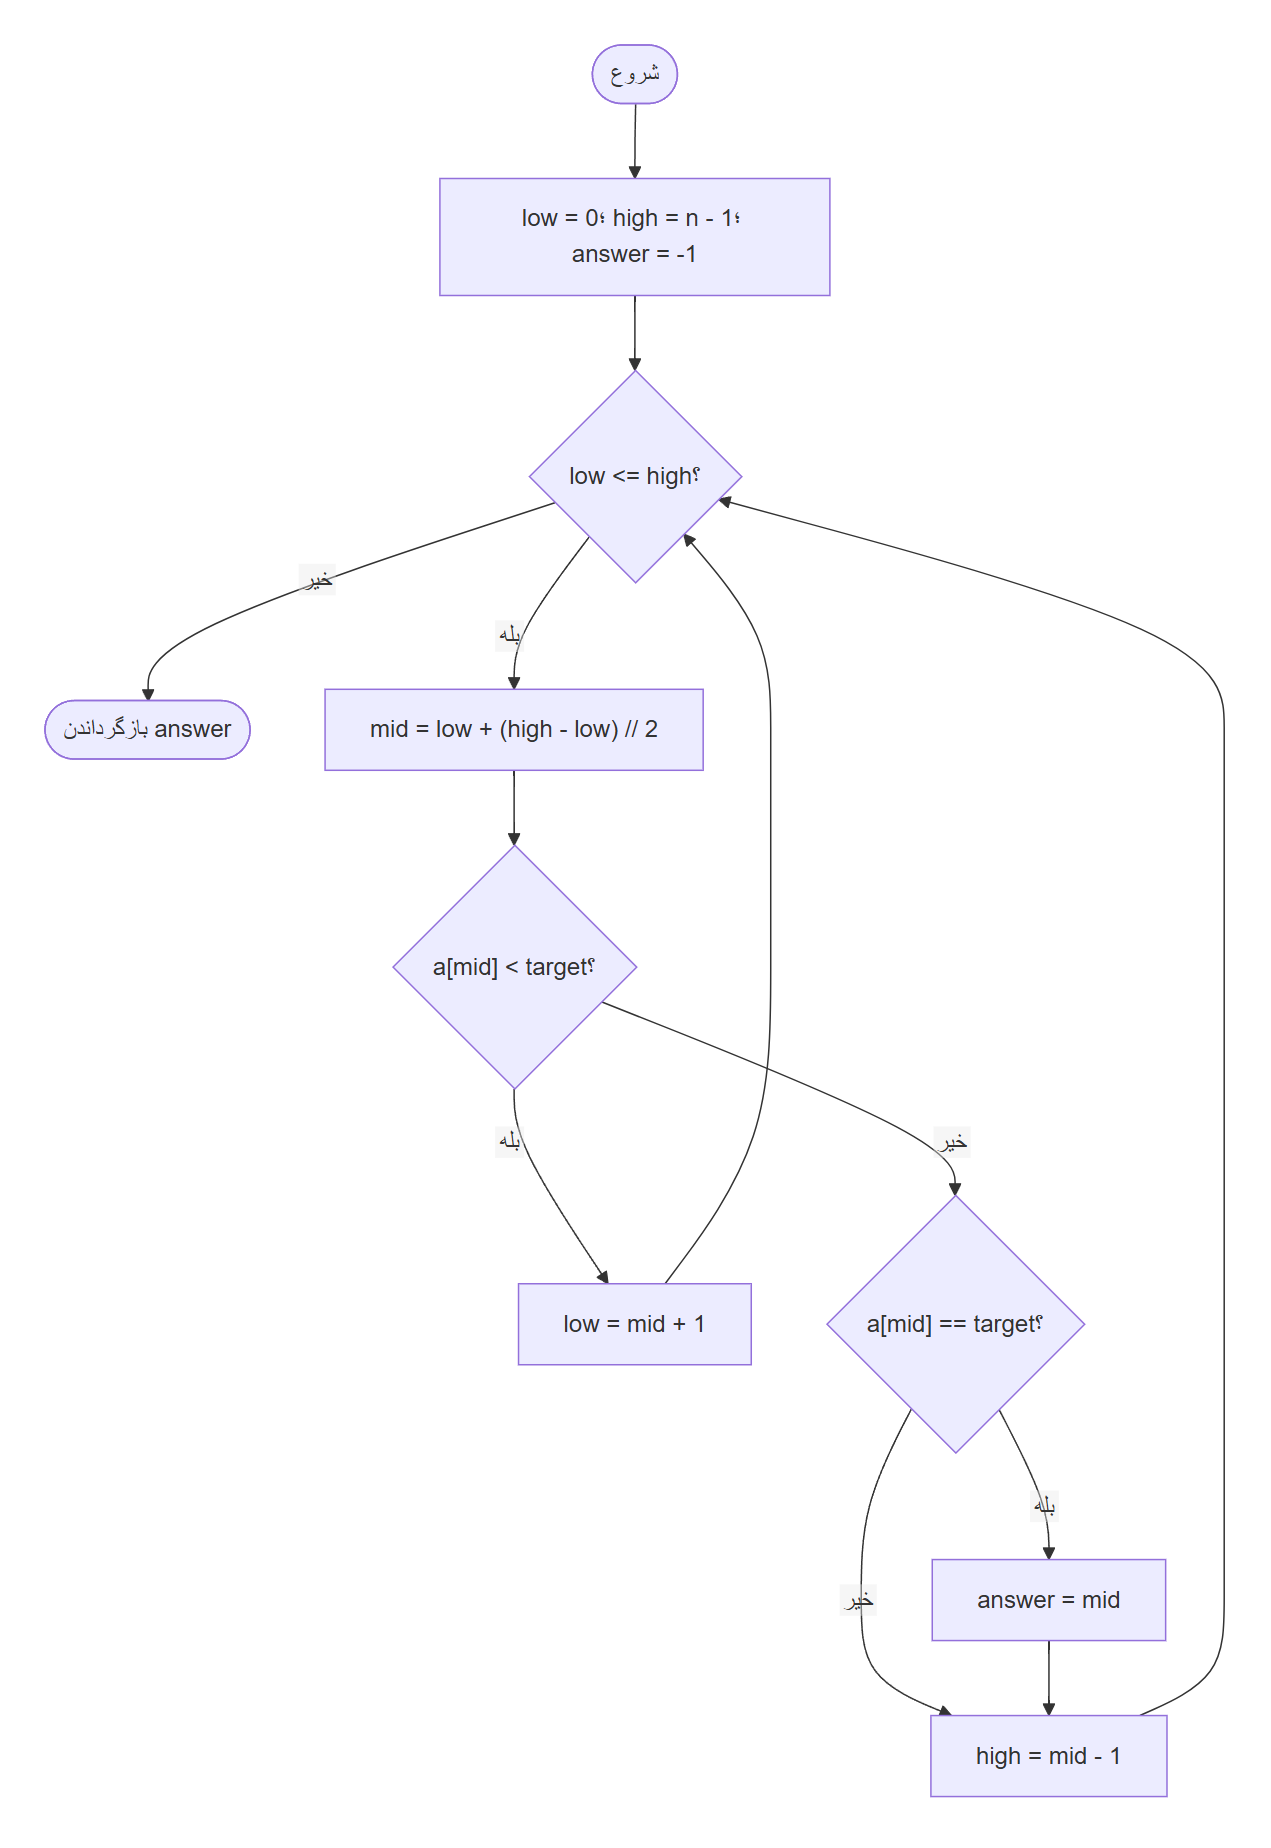

متن قابل ویرایش نمودار:

```mermaid
flowchart TD
    A([شروع]) --> B["low = 0؛ high = n - 1؛ answer = -1"]
    B --> C{"low <= high؟"}
    C -- خیر --> Z([بازگرداندن answer])
    C -- بله --> D["mid = low + (high - low) // 2"]
    D --> E{"a[mid] < target؟"}
    E -- بله --> F["low = mid + 1"]
    F --> C
    E -- خیر --> G{"a[mid] == target؟"}
    G -- بله --> H["answer = mid"]
    G -- خیر --> I["high = mid - 1"]
    H --> I
    I --> C
```


### فلوچارت جست‌وجوی دودویی بازگشتی

نمایش نمودار به‌صورت تصویر پیوست، بدون نیاز به اینترنت، انجام می‌شود.

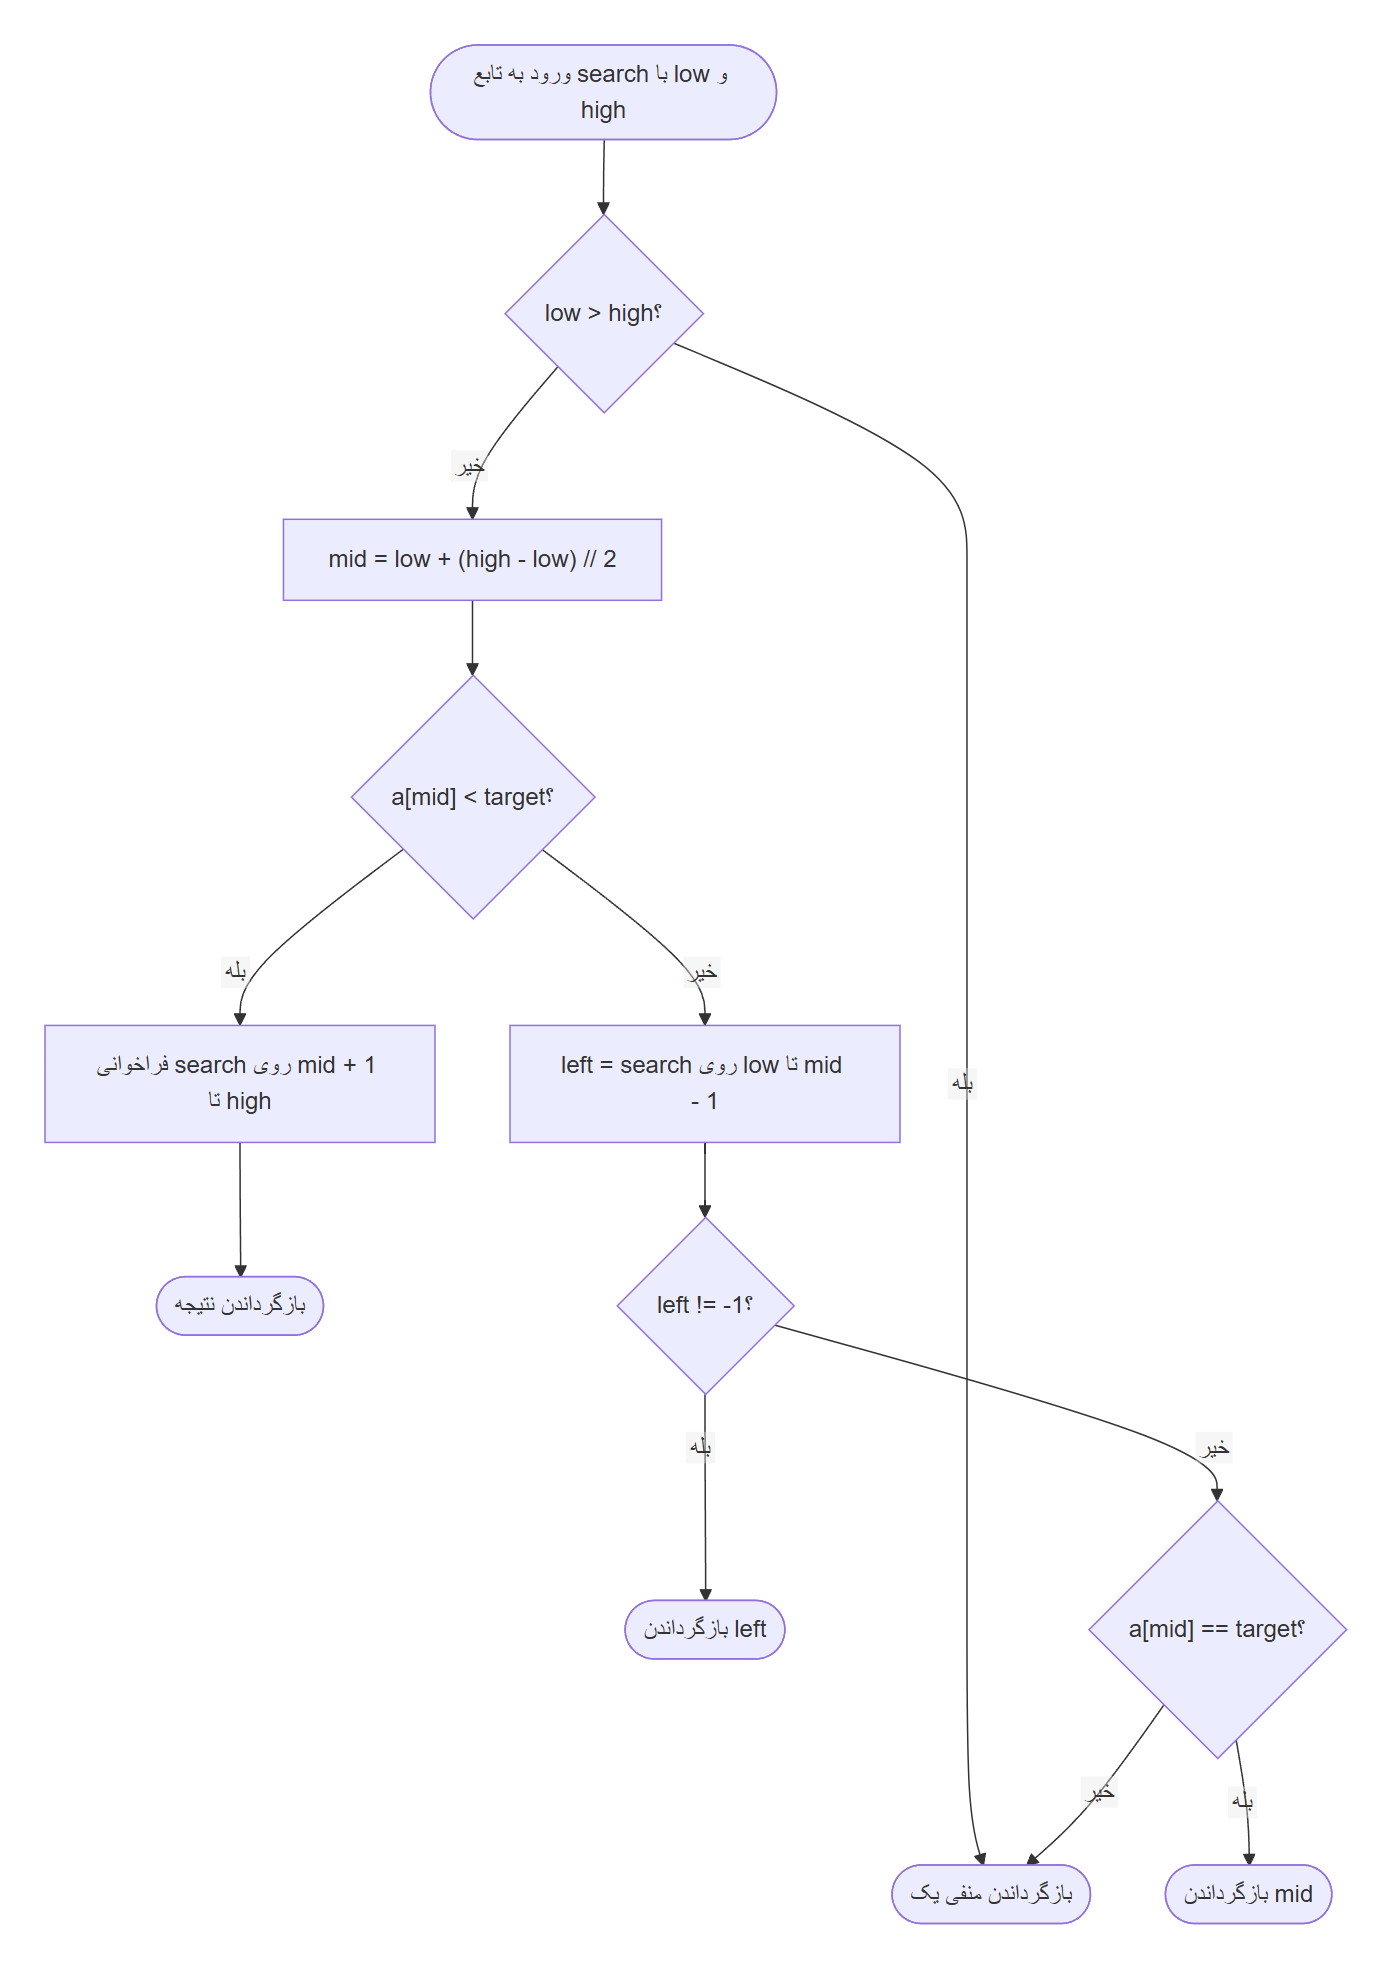

متن قابل ویرایش نمودار:

```mermaid
flowchart TD
    A([ورود به تابع search با low و high]) --> B{"low > high؟"}
    B -- بله --> C([بازگرداندن منفی یک])
    B -- خیر --> D["mid = low + (high - low) // 2"]
    D --> E{"a[mid] < target؟"}
    E -- بله --> F["فراخوانی search روی mid + 1 تا high"]
    F --> G([بازگرداندن نتیجه])
    E -- خیر --> H["left = search روی low تا mid - 1"]
    H --> I{"left != -1؟"}
    I -- بله --> J([بازگرداندن left])
    I -- خیر --> K{"a[mid] == target؟"}
    K -- بله --> L([بازگرداندن mid])
    K -- خیر --> C
```


In [2]:
def binary_search_iterative(a, target, trace=None):
    """بازگرداندن اندیس اولین رخداد در آرایه صعودی، یا منفی یک."""
    low, high, answer = 0, len(a) - 1, -1
    while low <= high:
        mid = low + (high - low) // 2
        if trace is not None:
            trace.append((low, mid, high, a[mid]))
        if a[mid] < target:
            low = mid + 1
        else:
            if a[mid] == target:
                answer = mid
            # حتی پس از یافتن مقدار، برای اولین رخداد به چپ ادامه می‌دهیم.
            high = mid - 1
    return answer


def binary_search_recursive(a, target, trace=None):
    """نسخه بازگشتی بدون ساخت برش یا کپی از آرایه."""
    def search(low, high):
        if low > high:
            return -1
        mid = low + (high - low) // 2
        if trace is not None:
            trace.append((low, mid, high, a[mid]))
        if a[mid] < target:
            return search(mid + 1, high)
        left = search(low, mid - 1)
        if left != -1:
            return left
        return mid if a[mid] == target else -1

    return search(0, len(a) - 1)


### مثال ردگیری

مثال هدف ۱۲ را در آرایهٔ دارای سه تکرار جست‌وجو می‌کند. ردگیری `Trace` قبل از تغییر کران‌ها ثبت می‌شود؛ جدول‌های دو نسخه باید یکسان باشند و پاسخ ۴ باشد.


نتیجه نسخه تکراری : 4


| مرحله | کران چپ `low` | میانه `mid` | کران راست `high` | مقدار میانه |
|---|---|---|---|---|
| گام 1 | 0 | 4 | 8 | 12 |
| گام 2 | 0 | 1 | 3 | 4 |
| گام 3 | 2 | 2 | 3 | 7 |
| گام 4 | 3 | 3 | 3 | 9 |

نتیجه نسخه بازگشتی : 4


| مرحله | کران چپ `low` | میانه `mid` | کران راست `high` | مقدار میانه |
|---|---|---|---|---|
| گام 1 | 0 | 4 | 8 | 12 |
| گام 2 | 0 | 1 | 3 | 4 |
| گام 3 | 2 | 2 | 3 | 7 |
| گام 4 | 3 | 3 | 3 | 9 |

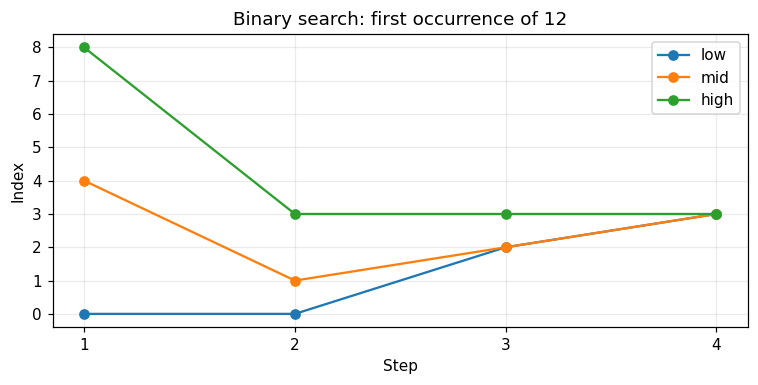

In [3]:
search_example = [2, 4, 7, 9, 12, 12, 12, 16, 20]
traces = {}
for label, function in [("تکراری", binary_search_iterative),
                        ("بازگشتی", binary_search_recursive)]:
    history = []
    answer = function(search_example, 12, history)
    assert answer == 4
    traces[label] = history
    print("نتیجه نسخه", label, ":", answer)
    show_table(["مرحله", "کران چپ `low`", "میانه `mid`", "کران راست `high`", "مقدار میانه"],
               [(f"گام {i}", *row) for i, row in enumerate(history, 1)])

assert traces["تکراری"] == traces["بازگشتی"]
fig, ax = plt.subplots(figsize=(7, 3.6))
for position, name in enumerate(("low", "mid", "high")):
    ax.plot(range(1, len(traces["تکراری"]) + 1),
            [row[position] for row in traces["تکراری"]], marker="o", label=name)
ax.set(xlabel="Step", ylabel="Index", title="Binary search: first occurrence of 12")
ax.set_xticks(range(1, len(traces["تکراری"]) + 1))
ax.legend()
fig.tight_layout()
plt.show()


### تحلیل و بهینه‌سازی جست‌وجو

زمان این نسخه‌ها برای اولین رخداد با رشد اندازه `Θ(log(n + 1))` است؛ برخلاف نسخهٔ معمول که روی برابری فوری برمی‌گردد، اینجا جست‌وجو بعد از برابری ادامه دارد. حافظهٔ تکراری `Θ(1)` و بازگشتی `Θ(log(n + 1))` برای پشتهٔ فراخوانی `Call Stack` است. ورودی خالی و تک‌عضوی هزینهٔ ثابت دارند. ردگیری فعال، حافظهٔ لگاریتمی جداگانه مصرف می‌کند.

بهبود تکراری، حذف سربار فراخوانی و کاهش مرتبهٔ حافظه است، نه کاهش مرتبهٔ زمان. کران‌ها از کپی خطی برش‌های آرایه جلوگیری می‌کنند. فرمول میانه از سرریز زبان‌های عدد ثابت جلوگیری می‌کند؛ در `Python` این ادعای سرعت نیست. بررسی پیش‌شرط یا مرتب‌سازی در هر جست‌وجو هزینهٔ اضافی خطی یا خطی‌لگاریتمی دارد. برای یک پرس‌وجو روی ورودی نامرتب، جست‌وجوی خطی `Linear Search` می‌تواند مناسب‌تر باشد.


### آزمون‌های جست‌وجو

بررسی‌ها شامل مرزها و همهٔ آرایه‌های نامنزولی با طول تا شش روی پنج مقدار است؛ پاسخ با مرجع خطی اولین رخداد مقایسه می‌شود. دو تابع نباید ورودی را تغییر دهند.


In [4]:
boundary_searches = [
    ("آرایه خالی", [], 1, -1),
    ("تک‌عضوی موفق", [5], 5, 0),
    ("تک‌عضوی ناموفق", [5], 2, -1),
    ("عضو ابتدا", [1, 3, 5], 1, 0),
    ("عضو انتها", [1, 3, 5], 5, 2),
    ("عنصر غایب بین اعضا", [1, 3, 5], 4, -1),
    ("عنصر کوچک‌تر از همه", [1, 3, 5], 0, -1),
    ("عنصر بزرگ‌تر از همه", [1, 3, 5], 6, -1),
    ("تکرار همه اعضا", [7, 7, 7, 7], 7, 0),
    ("تکرار در وسط", [1, 2, 2, 2, 3], 2, 1),
]
for _, data, target, expected in boundary_searches:
    for function in (binary_search_iterative, binary_search_recursive):
        before = data.copy()
        assert function(data, target) == expected
        assert data == before
show_table(["حالت", "آرایه", "هدف", "اندیس مورد انتظار"], boundary_searches)

binary_cases = 0
for size in range(7):
    for values in combinations_with_replacement(range(5), size):
        data = list(values)  # ترکیب‌ها خودشان نامنزولی هستند.
        for target in range(-1, 6):
            expected = next((i for i, value in enumerate(data) if value == target), -1)
            assert binary_search_iterative(data, target) == expected
            assert binary_search_recursive(data, target) == expected
            binary_cases += 1
print("بررسی جامع جست‌وجو:", binary_cases, "حالت برای هر نسخه؛ همه موفق بودند.")


| حالت | آرایه | هدف | اندیس مورد انتظار |
|---|---|---|---|
| آرایه خالی | [] | 1 | -1 |
| تک‌عضوی موفق | [5] | 5 | 0 |
| تک‌عضوی ناموفق | [5] | 2 | -1 |
| عضو ابتدا | [1, 3, 5] | 1 | 0 |
| عضو انتها | [1, 3, 5] | 5 | 2 |
| عنصر غایب بین اعضا | [1, 3, 5] | 4 | -1 |
| عنصر کوچک‌تر از همه | [1, 3, 5] | 0 | -1 |
| عنصر بزرگ‌تر از همه | [1, 3, 5] | 6 | -1 |
| تکرار همه اعضا | [7, 7, 7, 7] | 7 | 0 |
| تکرار در وسط | [1, 2, 2, 2, 3] | 2 | 1 |

بررسی جامع جست‌وجو: 3234 حالت برای هر نسخه؛ همه موفق بودند.


## تمرین دوم: مرتب‌سازی

ایدهٔ حبابی `Bubble Sort` رساندن بزرگ‌ترین عضو به انتهای بخش فعال با مقایسهٔ همسایه‌هاست؛ توقف زودهنگام `Early Exit` با نبودن جابجایی، بهترین حالت مرتب را خطی می‌کند.

ایدهٔ انتخابی `Selection Sort` یافتن کوچک‌ترین عضو بخش باقی‌مانده و جابجایی آن با سر آن بخش است؛ تعداد مقایسه‌ها در همهٔ حالت‌ها درجهٔ دو است.

ایدهٔ درجی `Insertion Sort` واردکردن عضو بعدی در پیشوند مرتب با انتقال مقدارهای بزرگ‌تر است؛ اعضای برابر جابجا نمی‌شوند. زمان `Θ(n + I)` است؛ وارونگی `Inversion` یک جفت با عضو چپ بزرگ‌تر از راست است و `I` تعداد این جفت‌هاست.

ایدهٔ ادغامی `Merge Sort` تقسیم و حل `Divide and Conquer` با نصف‌کردن بازه، حل دو نیمه و ادغام دو فهرست مرتب است. تابع `merge` یک بافر `Buffer` مشترک را پر می‌کند؛ انتخاب چپ در برابری پایداری می‌دهد. بازهٔ نیمه‌باز، کران راست را شامل نمی‌شود.

ایدهٔ سریع `Quick Sort` بخش‌بندی `Partition` با محور `Pivot` است. میانهٔ سه مقدار `Median-of-three` محور قطعی را می‌سازد؛ بخش‌بندی سه‌راهه `Three-way Partition`، اعضای برابر را از بازگشت حذف می‌کند. بازگشت فقط روی بخش کوچک‌تر، پشته را در بدترین حالت لگاریتمی نگه می‌دارد؛ زمان بدترین حالت همچنان درجهٔ دو است.


### فلوچارت مرتب‌سازی حبابی

نمایش نمودار به‌صورت تصویر پیوست، بدون نیاز به اینترنت، انجام می‌شود.

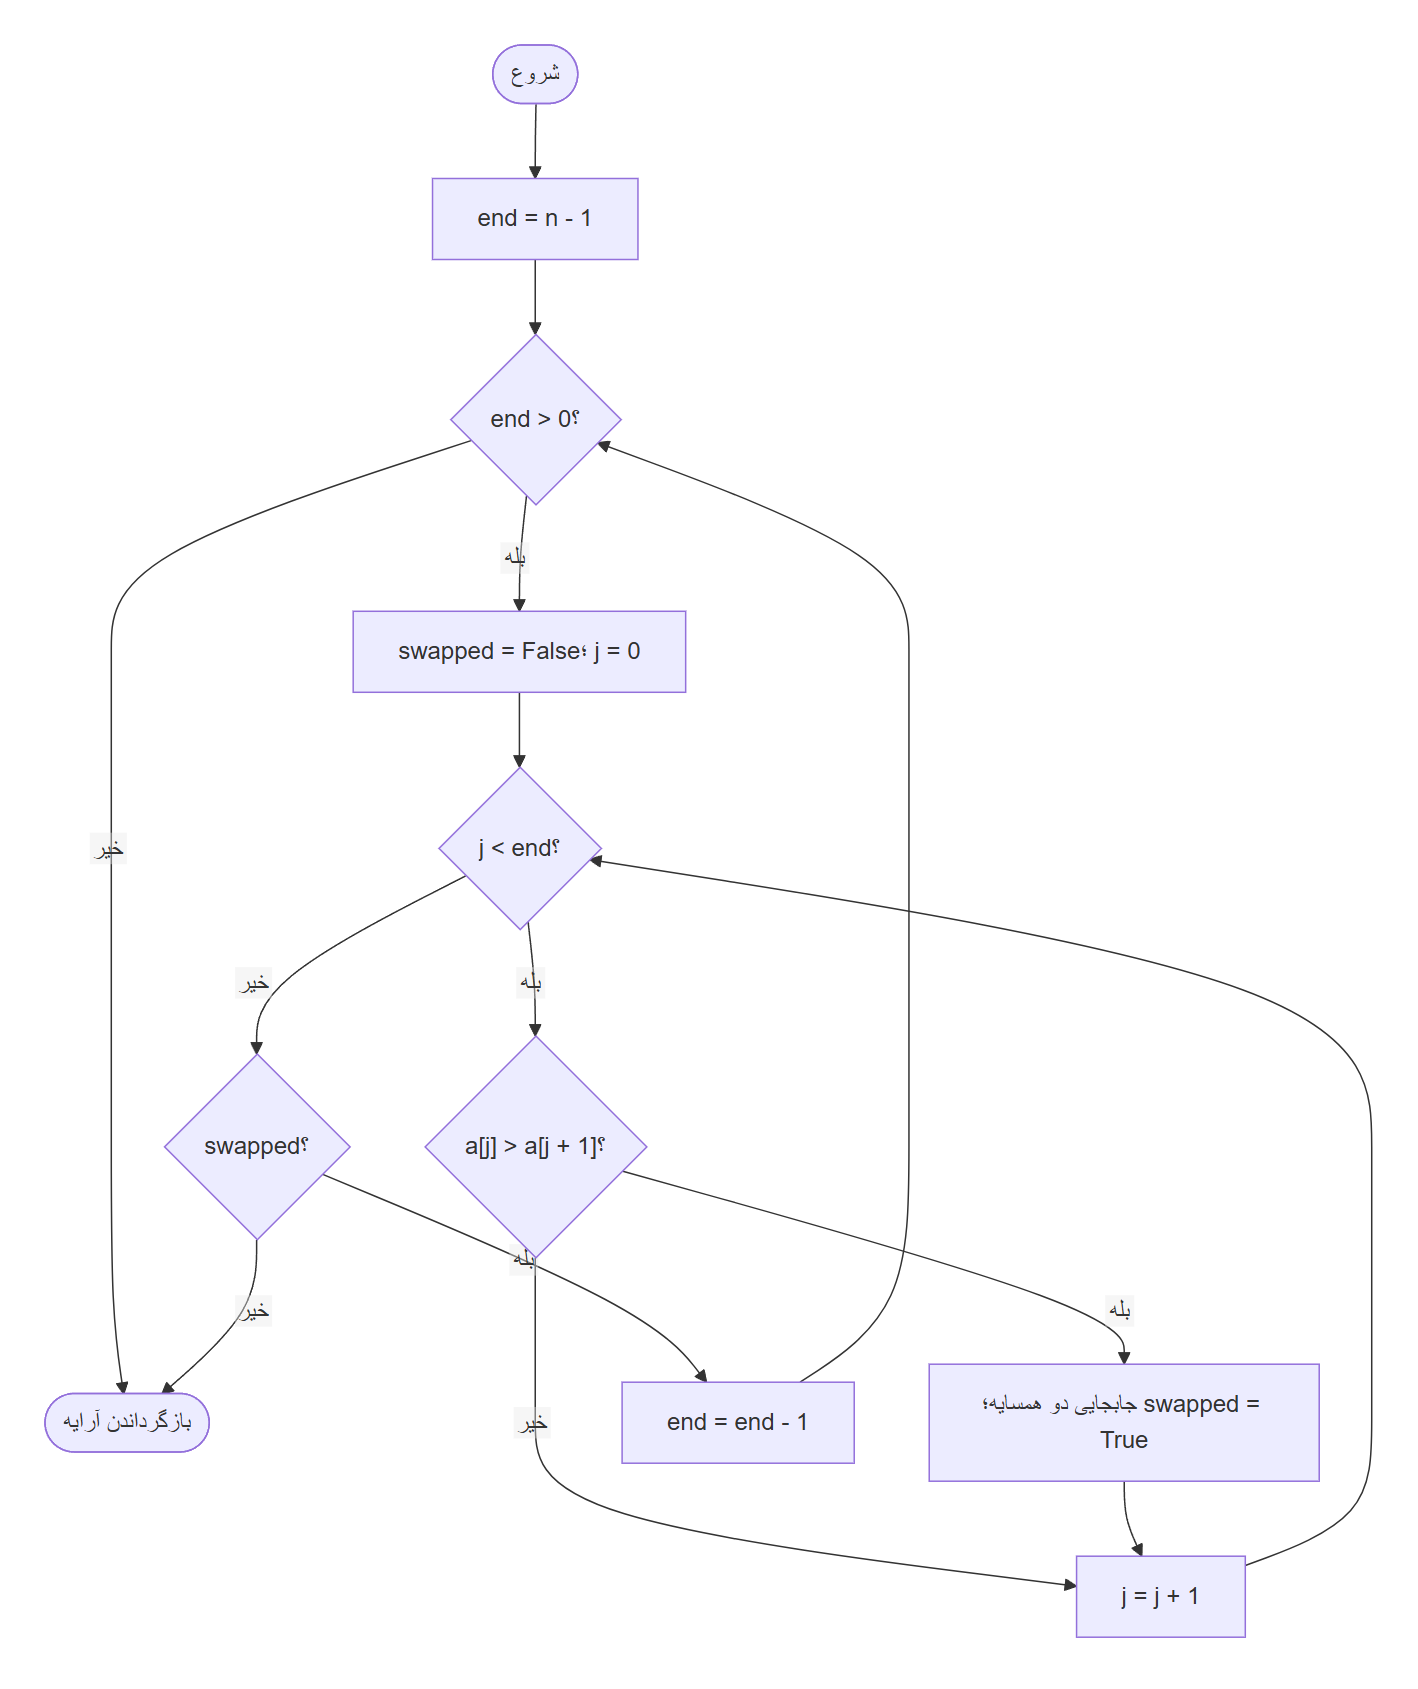

متن قابل ویرایش نمودار:

```mermaid
flowchart TD
    A([شروع]) --> B["end = n - 1"]
    B --> C{"end > 0؟"}
    C -- خیر --> Z([بازگرداندن آرایه])
    C -- بله --> D["swapped = False؛ j = 0"]
    D --> E{"j < end؟"}
    E -- بله --> F{"a[j] > a[j + 1]؟"}
    F -- بله --> G["جابجایی دو همسایه؛ swapped = True"]
    F -- خیر --> H["j = j + 1"]
    G --> H
    H --> E
    E -- خیر --> I{"swapped؟"}
    I -- خیر --> Z
    I -- بله --> J["end = end - 1"]
    J --> C
```


### فلوچارت مرتب‌سازی انتخابی

نمایش نمودار به‌صورت تصویر پیوست، بدون نیاز به اینترنت، انجام می‌شود.

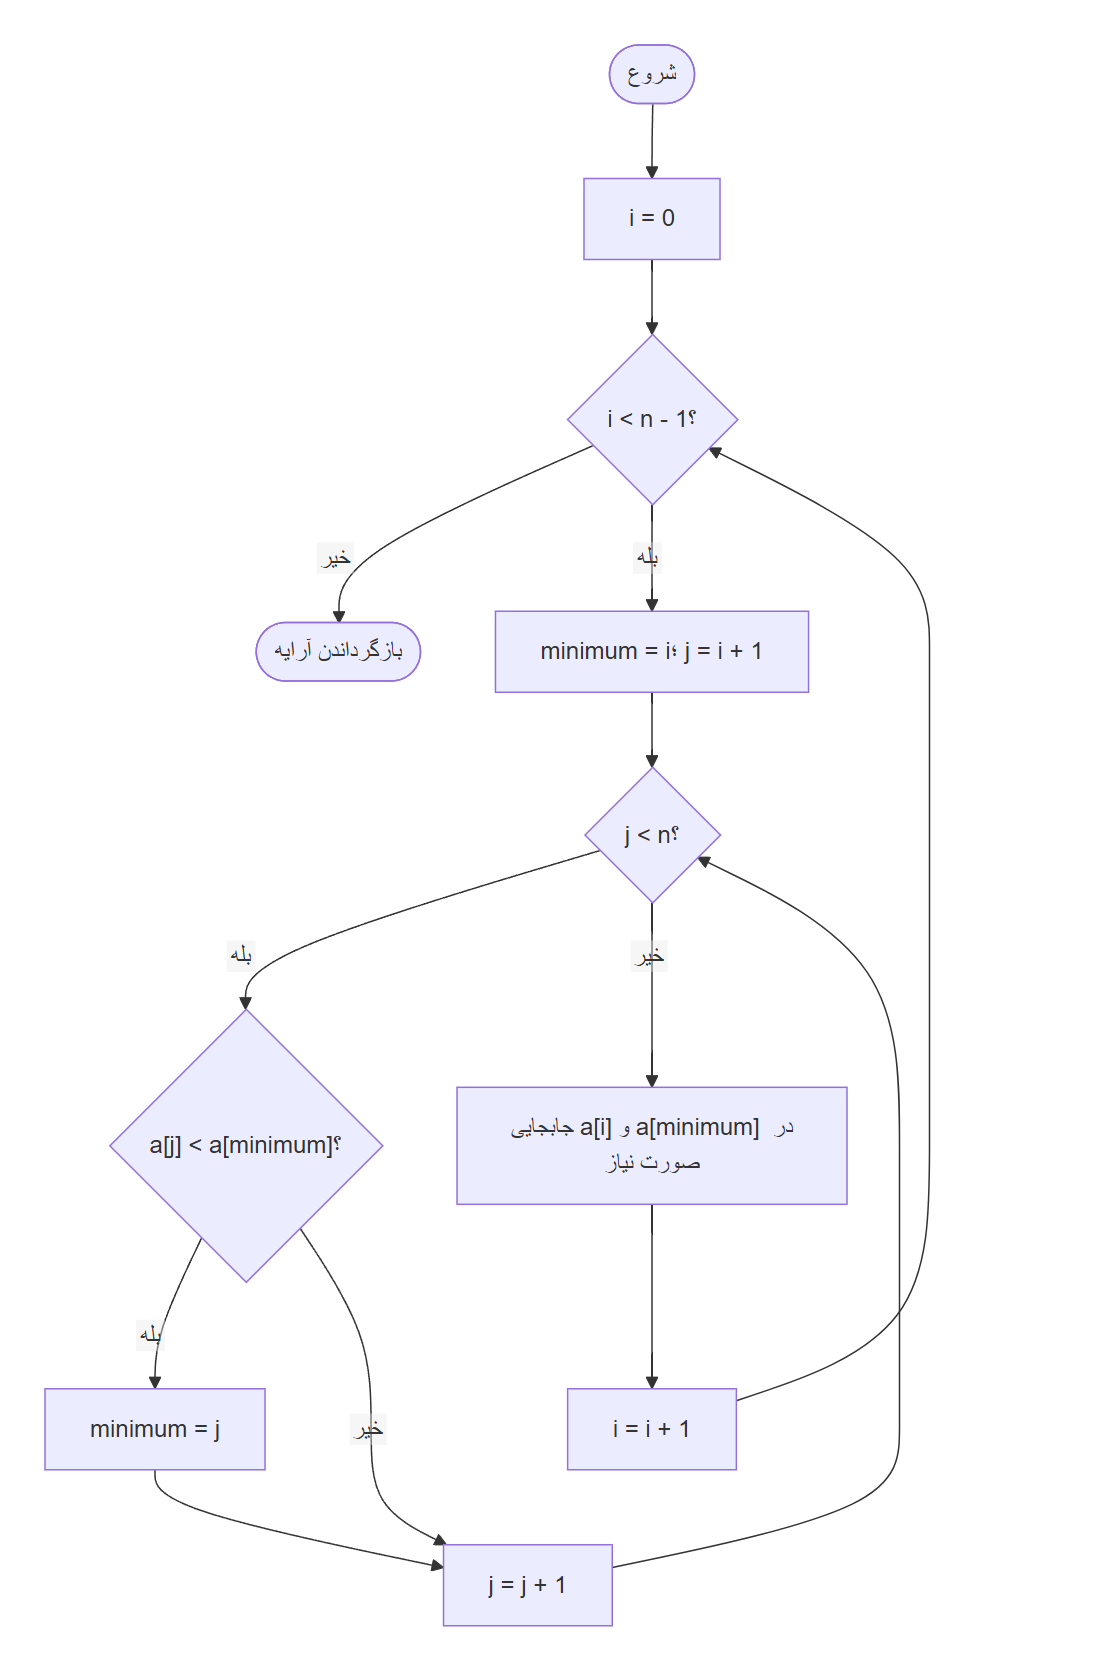

متن قابل ویرایش نمودار:

```mermaid
flowchart TD
    A([شروع]) --> B["i = 0"]
    B --> C{"i < n - 1؟"}
    C -- خیر --> Z([بازگرداندن آرایه])
    C -- بله --> D["minimum = i؛ j = i + 1"]
    D --> E{"j < n؟"}
    E -- بله --> F{"a[j] < a[minimum]؟"}
    F -- بله --> G["minimum = j"]
    F -- خیر --> H["j = j + 1"]
    G --> H
    H --> E
    E -- خیر --> I["جابجایی a[i] و a[minimum] در صورت نیاز"]
    I --> J["i = i + 1"]
    J --> C
```


### فلوچارت مرتب‌سازی درجی

نمایش نمودار به‌صورت تصویر پیوست، بدون نیاز به اینترنت، انجام می‌شود.

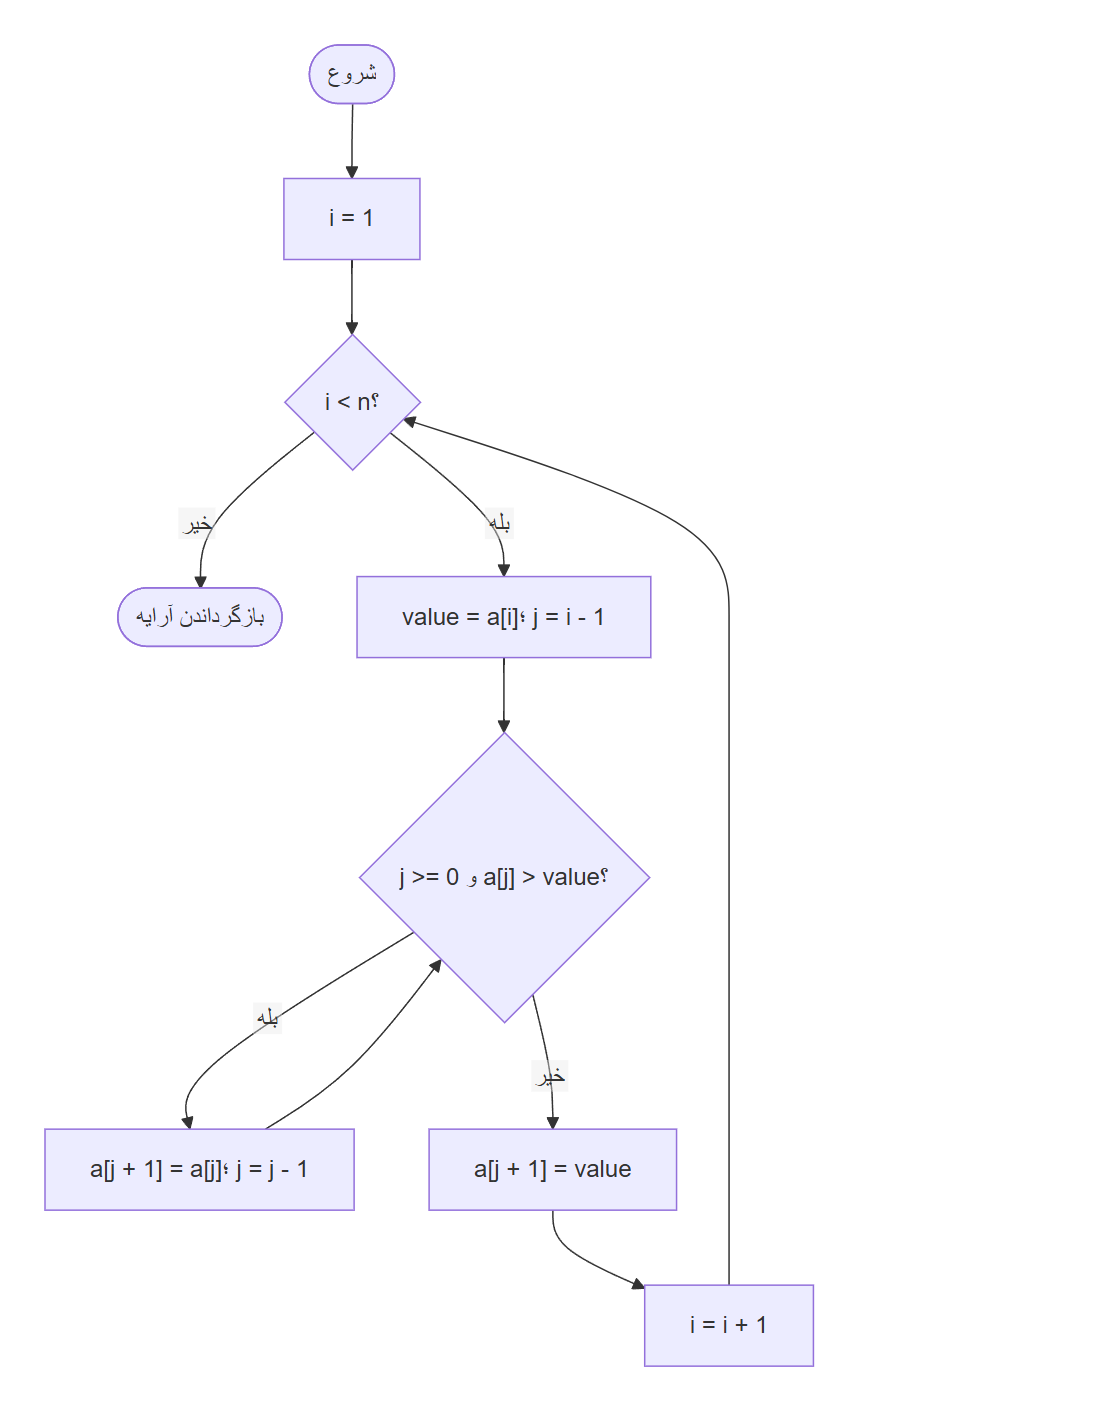

متن قابل ویرایش نمودار:

```mermaid
flowchart TD
    A([شروع]) --> B["i = 1"]
    B --> C{"i < n؟"}
    C -- خیر --> Z([بازگرداندن آرایه])
    C -- بله --> D["value = a[i]؛ j = i - 1"]
    D --> E{"j >= 0 و a[j] > value؟"}
    E -- بله --> F["a[j + 1] = a[j]؛ j = j - 1"]
    F --> E
    E -- خیر --> G["a[j + 1] = value"]
    G --> H["i = i + 1"]
    H --> C
```


### فلوچارت تابع بازگشتی مرتب‌سازی ادغامی

نمایش نمودار به‌صورت تصویر پیوست، بدون نیاز به اینترنت، انجام می‌شود.

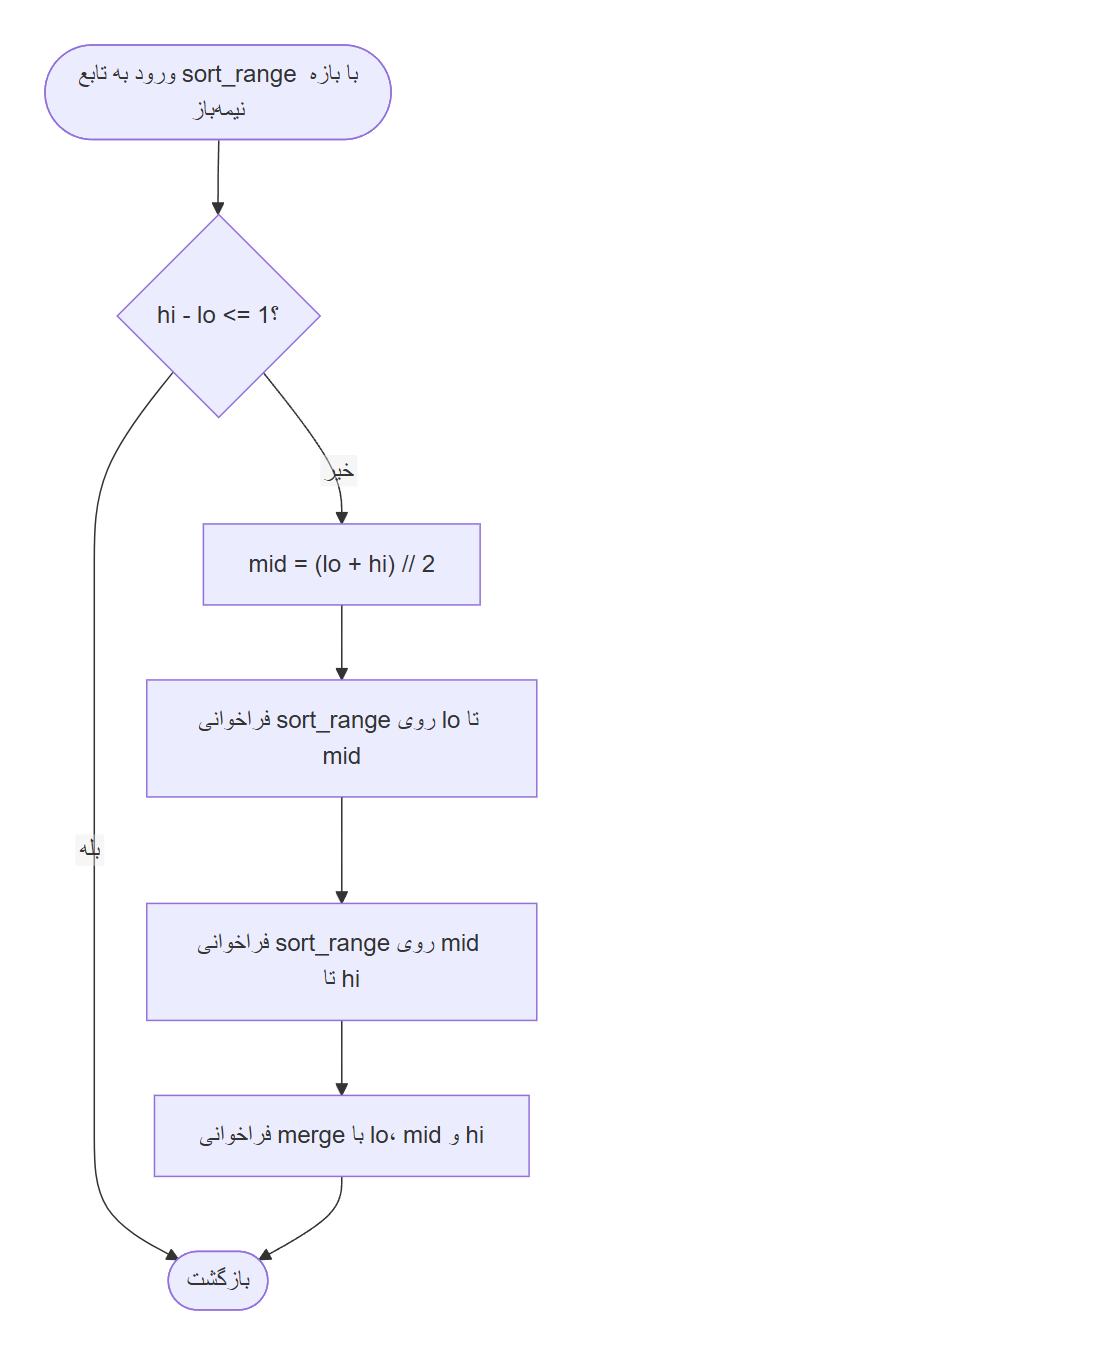

متن قابل ویرایش نمودار:

```mermaid
flowchart TD
    A([ورود به تابع sort_range با بازه نیمه‌باز]) --> B{"hi - lo <= 1؟"}
    B -- بله --> Z([بازگشت])
    B -- خیر --> C["mid = (lo + hi) // 2"]
    C --> D["فراخوانی sort_range روی lo تا mid"]
    D --> E["فراخوانی sort_range روی mid تا hi"]
    E --> F["فراخوانی merge با lo، mid و hi"]
    F --> Z
```


### فلوچارت تابع کمکی ادغام

نمایش نمودار به‌صورت تصویر پیوست، بدون نیاز به اینترنت، انجام می‌شود.

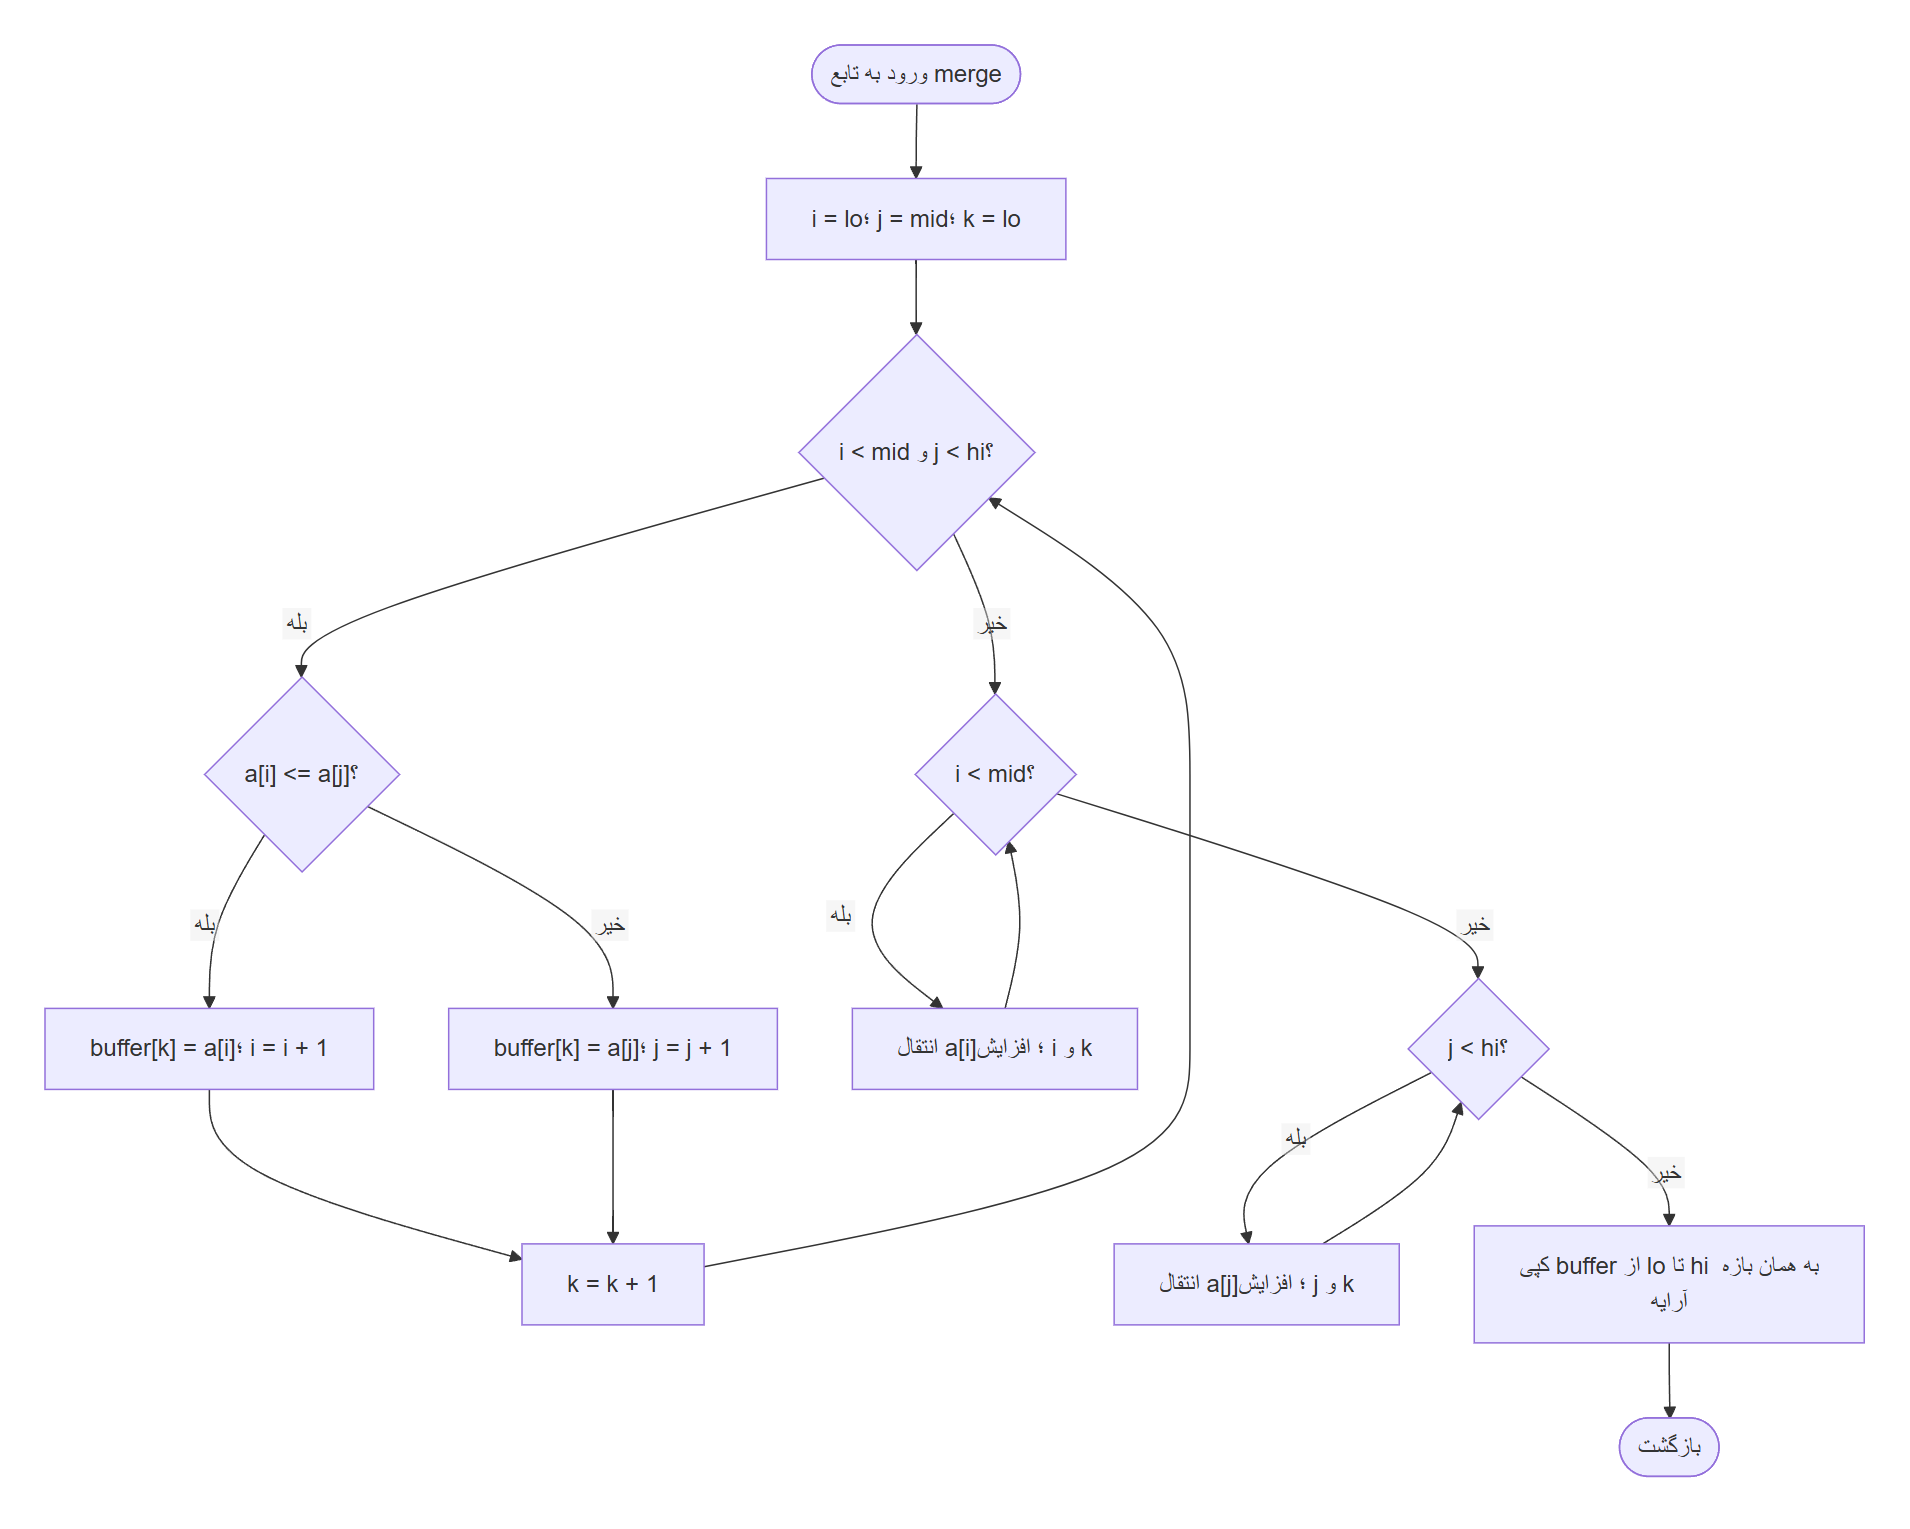

متن قابل ویرایش نمودار:

```mermaid
flowchart TD
    A([ورود به تابع merge]) --> B["i = lo؛ j = mid؛ k = lo"]
    B --> C{"i < mid و j < hi؟"}
    C -- بله --> D{"a[i] <= a[j]؟"}
    D -- بله --> E["buffer[k] = a[i]؛ i = i + 1"]
    D -- خیر --> F["buffer[k] = a[j]؛ j = j + 1"]
    E --> G["k = k + 1"]
    F --> G
    G --> C
    C -- خیر --> H{"i < mid؟"}
    H -- بله --> I["انتقال a[i]؛ افزایش i و k"]
    I --> H
    H -- خیر --> J{"j < hi؟"}
    J -- بله --> K["انتقال a[j]؛ افزایش j و k"]
    K --> J
    J -- خیر --> L["کپی buffer از lo تا hi به همان بازه آرایه"]
    L --> Z([بازگشت])
```


### فلوچارت مرتب‌سازی سریع با بازگشت روی بخش کوچک‌تر

نمایش نمودار به‌صورت تصویر پیوست، بدون نیاز به اینترنت، انجام می‌شود.

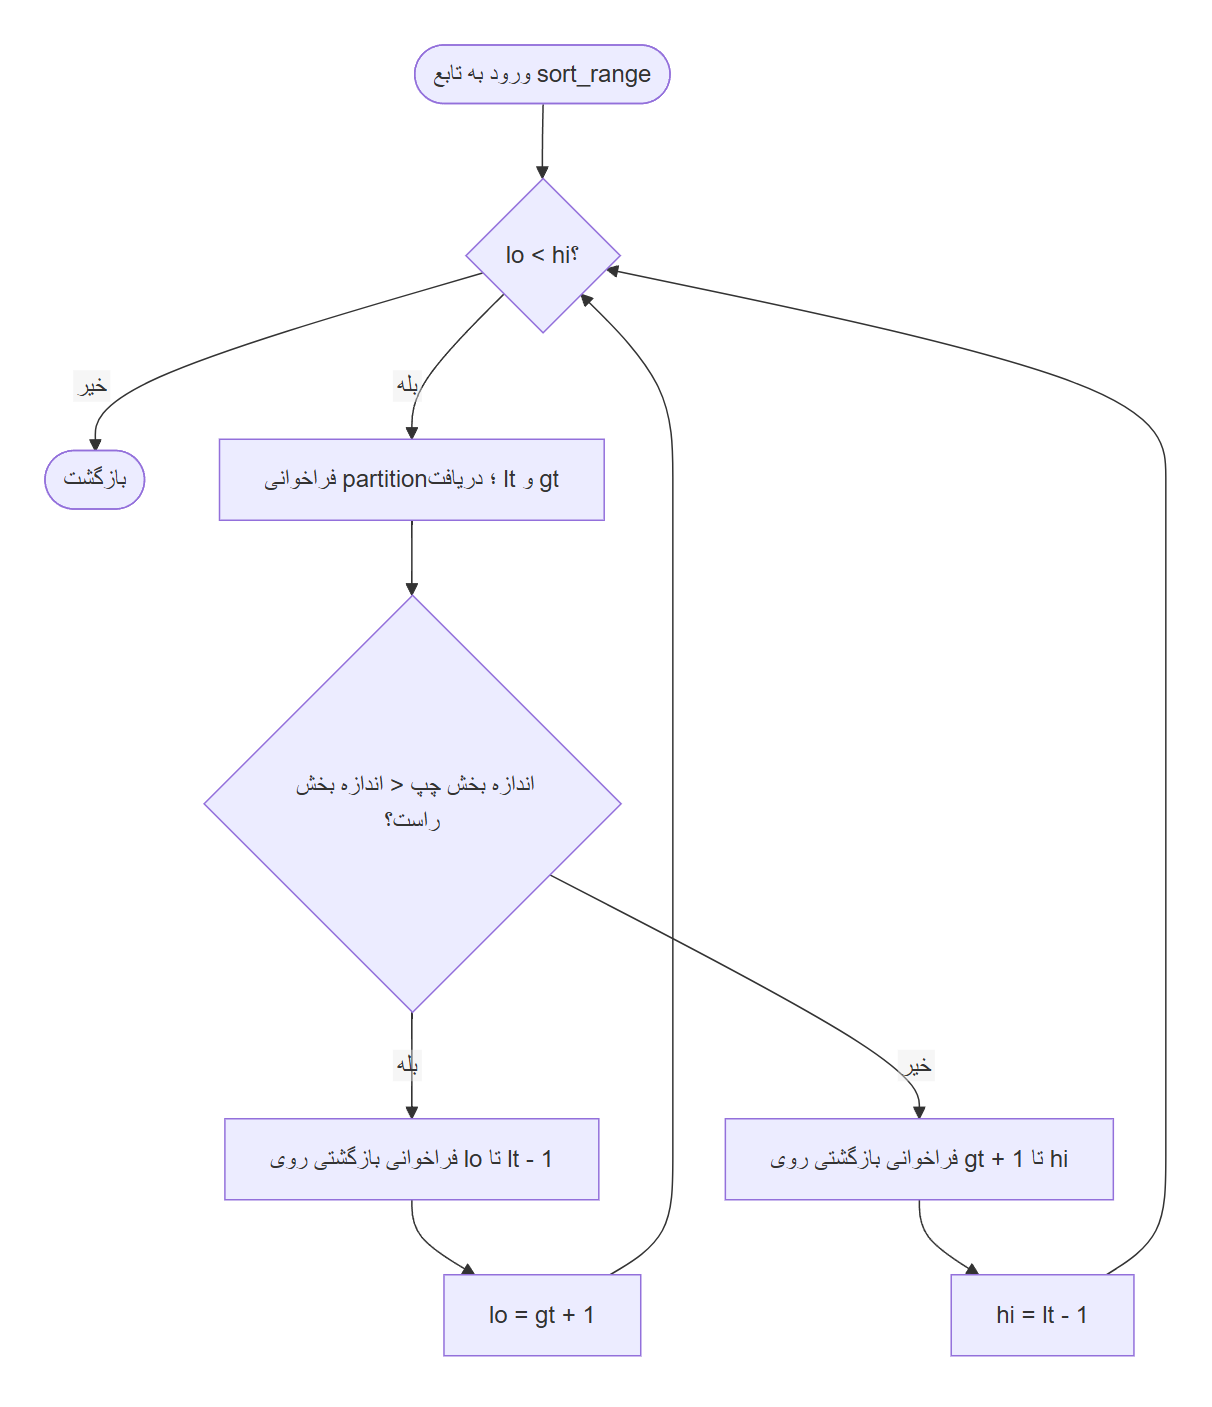

متن قابل ویرایش نمودار:

```mermaid
flowchart TD
    A([ورود به تابع sort_range]) --> B{"lo < hi؟"}
    B -- خیر --> Z([بازگشت])
    B -- بله --> C["فراخوانی partition؛ دریافت lt و gt"]
    C --> D{"اندازه بخش چپ < اندازه بخش راست؟"}
    D -- بله --> E["فراخوانی بازگشتی روی lo تا lt - 1"]
    E --> F["lo = gt + 1"]
    D -- خیر --> G["فراخوانی بازگشتی روی gt + 1 تا hi"]
    G --> H["hi = lt - 1"]
    F --> B
    H --> B
```


### فلوچارت تابع کمکی بخش‌بندی سه‌راهه

نمایش نمودار به‌صورت تصویر پیوست، بدون نیاز به اینترنت، انجام می‌شود.

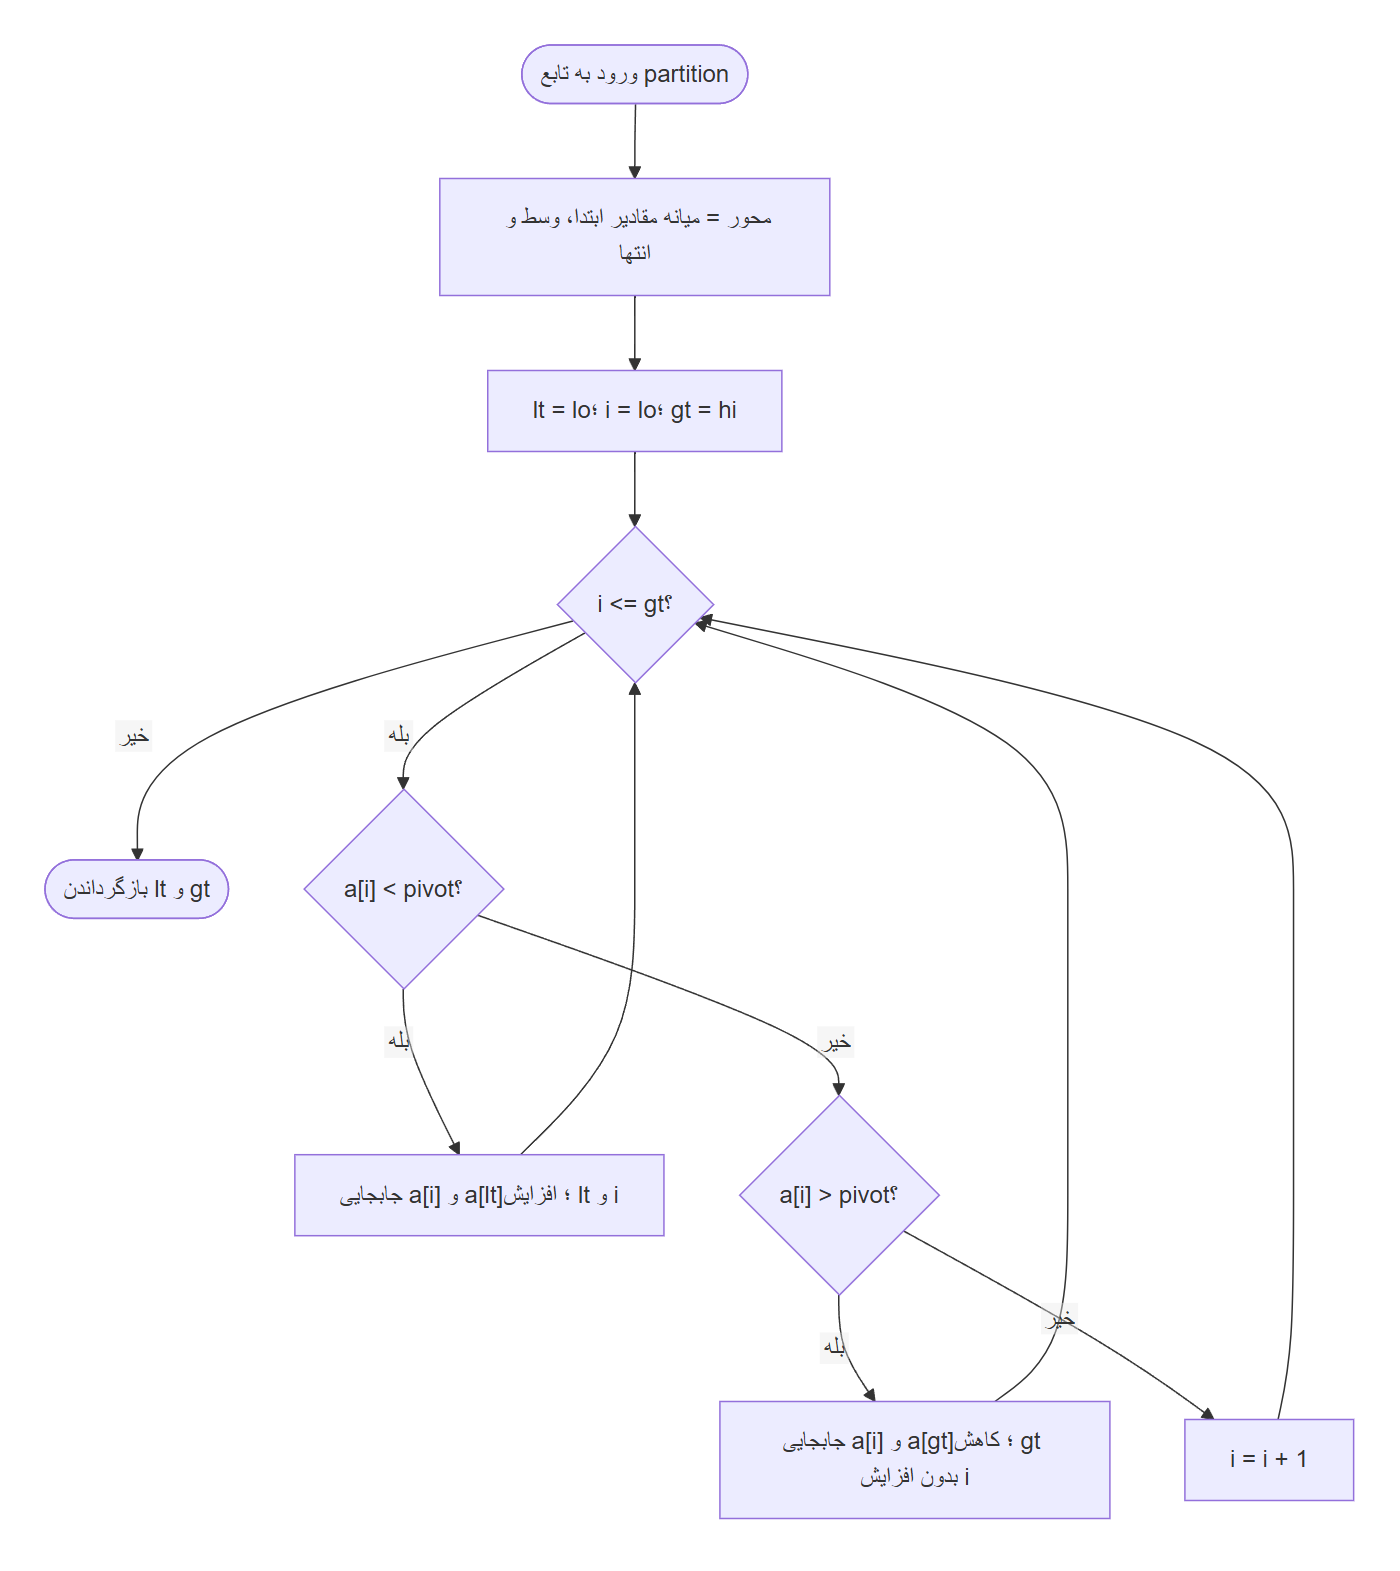

متن قابل ویرایش نمودار:

```mermaid
flowchart TD
    A([ورود به تابع partition]) --> B["محور = میانه مقادیر ابتدا، وسط و انتها"]
    B --> C["lt = lo؛ i = lo؛ gt = hi"]
    C --> D{"i <= gt؟"}
    D -- خیر --> Z([بازگرداندن lt و gt])
    D -- بله --> E{"a[i] < pivot؟"}
    E -- بله --> F["جابجایی a[i] و a[lt]؛ افزایش lt و i"]
    F --> D
    E -- خیر --> G{"a[i] > pivot؟"}
    G -- بله --> H["جابجایی a[i] و a[gt]؛ کاهش gt بدون افزایش i"]
    H --> D
    G -- خیر --> I["i = i + 1"]
    I --> D
```


### پیاده‌سازی پنج الگوریتم

توضیح‌ها کنار تصمیم‌های اصلی نوشته شده‌اند. پارامتر ردگیری در اندازه‌گیری خاموش است. هیچ‌کدام برای حل از مرتب‌ساز آماده استفاده نمی‌کنند.


In [5]:
def bubble_sort(a, trace=None):
    """مرتب‌سازی حبابی پایدار با توقف زودهنگام؛ تغییر همان فهرست."""
    for end in range(len(a) - 1, 0, -1):
        swapped = False
        for j in range(end):
            if a[j] > a[j + 1]:
                a[j], a[j + 1] = a[j + 1], a[j]
                swapped = True
        if trace is not None:
            trace.append({"event": "گذر", "detail": f"end={end}", "array": a.copy()})
        if not swapped:
            break
    return a


def selection_sort(a, trace=None):
    """مرتب‌سازی انتخابی معمول با جابجایی؛ ناپایدار و درجا."""
    for i in range(len(a) - 1):
        minimum = i
        for j in range(i + 1, len(a)):
            if a[j] < a[minimum]:
                minimum = j
        if minimum != i:
            a[i], a[minimum] = a[minimum], a[i]
        if trace is not None:
            trace.append({"event": "انتخاب", "detail": f"i={i}; minimum={minimum}", "array": a.copy()})
    return a


def insertion_sort(a, trace=None):
    """مرتب‌سازی درجی پایدار؛ مقدارهای بزرگ‌تر یک خانه جابجا می‌شوند."""
    for i in range(1, len(a)):
        value = a[i]
        j = i - 1
        while j >= 0 and a[j] > value:
            a[j + 1] = a[j]
            j -= 1
        a[j + 1] = value
        if trace is not None:
            trace.append({"event": "درج", "detail": f"i={i}; destination={j + 1}", "array": a.copy()})
    return a


def merge_sort(a, trace=None):
    """مرتب‌سازی ادغامی پایدار با یک بافر مشترک و بدون برش‌سازی."""
    buffer = [None] * len(a)

    def merge(lo, mid, hi):
        i, j, k = lo, mid, lo
        while i < mid and j < hi:
            # انتخاب نیمه چپ در حالت برابری، ترتیب اعضای برابر را حفظ می‌کند.
            if a[i] <= a[j]:
                buffer[k] = a[i]
                i += 1
            else:
                buffer[k] = a[j]
                j += 1
            k += 1
        while i < mid:
            buffer[k] = a[i]
            i += 1
            k += 1
        while j < hi:
            buffer[k] = a[j]
            j += 1
            k += 1
        for k in range(lo, hi):
            a[k] = buffer[k]
        if trace is not None:
            trace.append({"event": "ادغام", "detail": f"[{lo}:{mid}) + [{mid}:{hi})", "array": a.copy()})

    def sort_range(lo, hi):
        if hi - lo <= 1:
            return
        mid = (lo + hi) // 2
        if trace is not None:
            trace.append({"event": "تقسیم", "detail": f"[{lo}:{hi}) at {mid}", "array": a.copy()})
        sort_range(lo, mid)
        sort_range(mid, hi)
        merge(lo, mid, hi)

    sort_range(0, len(a))
    return a


def quick_sort(a, trace=None):
    """مرتب‌سازی سریع سه‌راهه؛ محور میانه سه و بازگشت روی بخش کوچک‌تر."""
    def median_of_three(first, middle, last):
        if first > middle:
            first, middle = middle, first
        if middle > last:
            middle, last = last, middle
        if first > middle:
            first, middle = middle, first
        return middle

    def partition(lo, hi):
        pivot = median_of_three(a[lo], a[(lo + hi) // 2], a[hi])
        lt, i, gt = lo, lo, hi
        # قبل از هر گام: چپ کوچک‌تر، وسط برابر، راست بزرگ‌تر، بقیه ناشناخته.
        while i <= gt:
            if a[i] < pivot:
                a[lt], a[i] = a[i], a[lt]
                lt += 1
                i += 1
            elif a[i] > pivot:
                a[i], a[gt] = a[gt], a[i]
                gt -= 1
                # عضو تازه رسیده به i هنوز بررسی نشده است.
            else:
                i += 1
        if trace is not None:
            trace.append({"event": "بخش‌بندی", "detail": f"lo={lo}; hi={hi}; pivot={pivot}; equal=[{lt}:{gt}]", "array": a.copy()})
        return lt, gt

    def sort_range(lo, hi):
        while lo < hi:
            lt, gt = partition(lo, hi)
            # بخش کوچک‌تر بازگشتی است؛ بخش بزرگ‌تر در همین حلقه ادامه می‌یابد.
            if lt - lo < hi - gt:
                sort_range(lo, lt - 1)
                lo = gt + 1
            else:
                sort_range(gt + 1, hi)
                hi = lt - 1

    sort_range(0, len(a) - 1)
    return a


ALGORITHMS = {
    "Bubble": bubble_sort, "Selection": selection_sort,
    "Insertion": insertion_sort, "Merge": merge_sort, "Quick": quick_sort,
}
PERSIAN_NAMES = {
    "Bubble": "حبابی", "Selection": "انتخابی", "Insertion": "درجی",
    "Merge": "ادغامی", "Quick": "سریع",
}


### مثال‌های مرحله‌به‌مرحله

مثال مشترک زیر برای هر پنج الگوریتم به یک پاسخ می‌رسد. برای روش‌های ساده هر گذر یا درج و برای روش‌های بازگشتی هر تقسیم، ادغام یا بخش‌بندی نشان داده می‌شود. جزئیات بازهٔ ادغامی نیمه‌باز و بازهٔ سریع بسته‌اند.

```text
[5, 2, 4, 2, 1] → [1, 2, 2, 4, 5]
```


In [6]:
example = [5, 2, 4, 2, 1]
example_traces = {}
for name, function in ALGORITHMS.items():
    data, history = example.copy(), []
    result = function(data, history)
    assert result is data and result == [1, 2, 2, 4, 5]
    example_traces[name] = history
    display(Markdown(f"### مراحل مرتب‌سازی {PERSIAN_NAMES[name]}"))
    print("ورودی:", example)
    show_table(["مرحله", "رویداد", "جزئیات", "آرایه پس از رویداد"],
               [(f"گام {i}", row["event"], f'`{row["detail"]}`', f'`{row["array"]}`')
                for i, row in enumerate(history, 1)])


### مراحل مرتب‌سازی حبابی

ورودی: [5, 2, 4, 2, 1]


| مرحله | رویداد | جزئیات | آرایه پس از رویداد |
|---|---|---|---|
| گام 1 | گذر | `end=4` | `[2, 4, 2, 1, 5]` |
| گام 2 | گذر | `end=3` | `[2, 2, 1, 4, 5]` |
| گام 3 | گذر | `end=2` | `[2, 1, 2, 4, 5]` |
| گام 4 | گذر | `end=1` | `[1, 2, 2, 4, 5]` |

### مراحل مرتب‌سازی انتخابی

ورودی: [5, 2, 4, 2, 1]


...

ورودی: [5, 2, 4, 2, 1]


| مرحله | رویداد | جزئیات | آرایه پس از رویداد |
|---|---|---|---|
| گام 1 | تقسیم | `[0:5) at 2` | `[5, 2, 4, 2, 1]` |
| گام 2 | تقسیم | `[0:2) at 1` | `[5, 2, 4, 2, 1]` |
| گام 3 | ادغام | `[0:1) + [1:2)` | `[2, 5, 4, 2, 1]` |
| گام 4 | تقسیم | `[2:5) at 3` | `[2, 5, 4, 2, 1]` |
| گام 5 | تقسیم | `[3:5) at 4` | `[2, 5, 4, 2, 1]` |
| گام 6 | ادغام | `[3:4) + [4:5)` | `[2, 5, 4, 1, 2]` |
| گام 7 | ادغام | `[2:3) + [3:5)` | `[2, 5, 1, 2, 4]` |
| گام 8 | ادغام | `[0:2) + [2:5)` | `[1, 2, 2, 4, 5]` |

### مراحل مرتب‌سازی سریع

ورودی: [5, 2, 4, 2, 1]


| مرحله | رویداد | جزئیات | آرایه پس از رویداد |
|---|---|---|---|
| گام 1 | بخش‌بندی | `lo=0; hi=4; pivot=4; equal=[3:3]` | `[1, 2, 2, 4, 5]` |
| گام 2 | بخش‌بندی | `lo=0; hi=2; pivot=2; equal=[1:2]` | `[1, 2, 2, 4, 5]` |

### جدول مقایسهٔ نظری

جدول برای نسخه‌های دقیق نوت‌بوک، ورودی با رشد `n`، مقایسهٔ ثابت و بدون ردگیری است. زمان متوسط حبابی، انتخابی و درجی با مدل جایگشت تصادفی کلیدهای متمایز بیان شده است؛ زمان متوسط سریع نیز به همین فرض وابسته است. دربارهٔ ادغامی این تمایز اثری ندارد.

| الگوریتم | بهترین زمان | زمان متوسط | بدترین زمان | حافظهٔ کمکی | پایدار | درجا با احتساب پشته |
|---|---|---|---|---|---|---|
| مرتب‌سازی حبابی با توقف | `Θ(n)` | `Θ(n²)` | `Θ(n²)` | `Θ(1)` | بله | بله |
| مرتب‌سازی انتخابی | `Θ(n²)` | `Θ(n²)` | `Θ(n²)` | `Θ(1)` | خیر | بله |
| مرتب‌سازی درجی | `Θ(n)` | `Θ(n²)` | `Θ(n²)` | `Θ(1)` | بله | بله |
| مرتب‌سازی ادغامی با بافر | `Θ(n log n)` | `Θ(n log n)` | `Θ(n log n)` | `Θ(n)` | بله | خیر |
| مرتب‌سازی سریع سه‌راهه | `Θ(n)` برای اعضای یکسان | `Θ(n log n)` با فرض مذکور | `Θ(n²)` | `O(log n)` در بدترین حالت؛ ثابت برای اعضای یکسان | خیر | خیر؛ بخش‌بندی داخل آرایه است |

شاهد پایداری: ورودی برچسب‌دار زیر را فقط با عدد مقایسه کنید. نسخه‌های حبابی، درجی و ادغامی ترتیب دو برچسب برابر را حفظ می‌کنند؛ نسخه‌های انتخابی و سریع در همین مثال آن را جابجا می‌کنند. نوت‌بوک این شاهد را اجرا و برای سه الگوریتم پایدار، صدها حالت برچسب‌دار دیگر را نیز بررسی می‌کند.

```text
input:     [2a, 2b, 1c]
stable:    [1c, 2a, 2b]
unstable:  [1c, 2b, 2a]
```

### بهبودهای ممکن و حدود ادعا

- بهبود حبابی با توقف زودهنگام، بهترین حالت آرایهٔ مرتب را از درجهٔ دو به خطی تغییر می‌دهد؛ متوسط و بدترین حالت همچنان درجهٔ دو هستند.
- بهبود درجی روی دادهٔ نزدیک به مرتب از کم‌بودن وارونگی‌ها ناشی می‌شود. جست‌وجوی دودویی جای درج می‌تواند تعداد مقایسه‌ها را کم کند، ولی انتقال اعضا در بدترین حالت همچنان درجهٔ دو است.
- بهبود انتخابی با حذف جابجایی غیرضروری تنها ثابت‌های اجرا را عوض می‌کند؛ بررسی تمام اعضای باقی‌مانده حذف نمی‌شود.
- بهبود ادغامی با بافر مشترک تخصیص‌های اضافی را کاهش می‌دهد. بررسی مرز دو نیمه پیش از ادغام می‌تواند بهترین حالت نسخه‌ای متفاوت را خطی کند؛ در کد فعلی این تغییر پیاده‌سازی نشده و جدول آن را فرض نمی‌کند.
- بهبود سریع با میانهٔ سه و بخش‌بندی سه‌راهه در ورودی‌های خاص مفید است، ولی تضمین بدترین زمان بهتر نمی‌دهد. بازگشت فقط روی بخش کوچک‌تر، بهبود اثبات‌پذیر حافظه است. محور تصادفی زمان مورد انتظار را با فرض تصادفی‌سازی مناسب می‌دهد؛ روش ترکیبی درون‌نگر `Introsort` با تغییر به مرتب‌سازی توده‌ای `Heap Sort` در عمق زیاد می‌تواند تضمین بدترین زمان خطی‌لگاریتمی بدهد؛ این دو روش در این تمرین پیاده‌سازی نشده‌اند.


### بررسی صحت و پایداری

بررسی جامع تمام دنباله‌های تا طول شش روی چهار عدد، نمونه‌های تصادفی و مرزها را با `sorted()` مقایسه می‌کند. مرجع در اینجا فقط برای آزمون استفاده می‌شود. پایداری با رکوردهای برچسب‌دار سنجیده می‌شود؛ مقایسه فقط به کلید عددی نگاه می‌کند. آزمون شاهد ناپایداری برای انتخابی و سریع هم وجود دارد. آزمون‌های موفق، استدلال درستی `README.md` را تکمیل می‌کنند و جای اثبات را نمی‌گیرند.


In [7]:
sort_cases = 0
# همه دنباله‌های با طول صفر تا شش، روی الفبای چهار عدد طبیعی.
for size in range(7):
    for values in product(range(4), repeat=size):
        expected = sorted(values)  # استفاده از مرجع فقط برای بررسی صحت.
        for name, function in ALGORITHMS.items():
            data = list(values)
            assert function(data) is data
            assert data == expected, (name, values, data)
        sort_cases += 1

test_rng = random.Random(SEED + 1)
explicit_cases = [[], [0], [7], [2, 2, 2], [0, 10**30, 3, 0],
                  list(range(100)), list(range(100, -1, -1))]
random_cases = [[test_rng.randrange(1000) for _ in range(test_rng.randrange(201))]
                for _ in range(200)]
for values in explicit_cases + random_cases:
    expected = sorted(values)
    for function in ALGORITHMS.values():
        data = values.copy()
        assert function(data) is data
        assert data == expected
print("بررسی مرتب‌سازی:", sort_cases, "دنباله جامع و", len(explicit_cases + random_cases),
      "حالت مرزی و تصادفی برای هر الگوریتم؛ همه موفق بودند.")

class Tagged:
    """مقایسه فقط بر اساس کلید؛ برچسب برای تشخیص ترتیب اعضای برابر است."""
    def __init__(self, key, tag):
        self.key, self.tag = key, tag
    def __lt__(self, other):
        return self.key < other.key
    def __gt__(self, other):
        return self.key > other.key
    def __le__(self, other):
        return self.key <= other.key
    def __repr__(self):
        return f"{self.key}{self.tag}"

stability_rows = []
for name, function in ALGORITHMS.items():
    data = [Tagged(2, "a"), Tagged(2, "b"), Tagged(1, "c")]
    function(data)
    equal_tags = [item.tag for item in data if item.key == 2]
    preserved = equal_tags == ["a", "b"]
    if name in ("Bubble", "Insertion", "Merge"):
        assert preserved
    else:
        assert not preserved  # همین مثال، شاهد ناپایداری این نسخه‌هاست.
    stability_rows.append((PERSIAN_NAMES[name], f"`{data}`", "بله" if preserved else "خیر"))
show_table(["الگوریتم", "خروجی برچسب‌دار", "حفظ ترتیب دو عضو برابر در مثال"], stability_rows)

for values in product(range(3), repeat=5):
    for name in ("Bubble", "Insertion", "Merge"):
        data = [Tagged(key, str(i)) for i, key in enumerate(values)]
        ALGORITHMS[name](data)
        assert [(item.key, item.tag) for item in data] == [
            (item.key, item.tag) for item in sorted(
                [Tagged(key, str(i)) for i, key in enumerate(values)], key=lambda item: item.key)]
print("بررسی پایداری:", 3 * 3**5, "اجرای برچسب‌دار برای سه الگوریتم پایدار، موفق بود.")


بررسی مرتب‌سازی: 5461 دنباله جامع و 207 حالت مرزی و تصادفی برای هر الگوریتم؛ همه موفق بودند.


| الگوریتم | خروجی برچسب‌دار | حفظ ترتیب دو عضو برابر در مثال |
|---|---|---|
| حبابی | `[1c, 2a, 2b]` | بله |
| انتخابی | `[1c, 2b, 2a]` | خیر |
| درجی | `[1c, 2a, 2b]` | بله |
| ادغامی | `[1c, 2a, 2b]` | بله |
| سریع | `[1c, 2b, 2a]` | خیر |

بررسی پایداری: 729 اجرای برچسب‌دار برای سه الگوریتم پایدار، موفق بود.


### روش اندازه‌گیری تجربی

روش آزمایش از بذر تصادفی `Seed` ثابت زیر و چهار اندازه استفاده می‌کند. در هر اندازه پنج نمونه ساخته می‌شود؛ همهٔ الگوریتم‌ها در هر تکرار دقیقاً یک ورودی مشترک دارند. ورودی تصادفی از صفر تا ده برابر اندازه است؛ ورودی مرتب و معکوس از همان داده ساخته می‌شوند؛ ورودی پرتکرار فقط پنج مقدار ممکن دارد. ثابت‌بودن بذر ورودی را بازتولید می‌کند، ولی زمان دقیق به دستگاه و وضعیت آن وابسته است.

```text
SEED = 20260930
SIZES = (32, 128, 512, 2048)
REPEATS = 5
```

اندازه‌گیری با ساعت یکنواخت `perf_counter_ns` فقط فراخوانی تابع مرتب‌سازی را دربرمی‌گیرد. تولید داده، مرتب‌سازی مرجع، کپی ورودی، انتخاب تصادفی ترتیب الگوریتم‌ها، بررسی صحت و رسم نمودار خارج از زمان‌گیری انجام می‌شوند. تخصیص بافر ادغامی و سربار فراخوانی و بازگشت جزو هزینهٔ خود الگوریتم‌اند و داخل زمان می‌مانند. گرم‌کردن اولیه `Warm-up` سه اجرا دارد و زمانش گزارش نمی‌شود. ردگیری خاموش است؛ در مجموع ۴۰۰ اجرای اندازه‌گیری‌شده داریم.

گزارش نوت‌بوک برای هر نوع ورودی یک جدول میانه `Median` دارد. نمودار اول میانه و ناحیهٔ میان چارک اول و سوم، یعنی دامنهٔ بین‌چارکی `Interquartile Range` را نشان می‌دهد. نمودار دوم برای بزرگ‌ترین اندازه، میانه و کمینه تا بیشینه را مقایسه می‌کند. محور زمان لگاریتمی است؛ برابر بودن فاصلهٔ عمودی به معنی نسبت زمانی برابر است، نه اختلاف زمانی برابر. برچسب‌های نمودار انگلیسی‌اند تا به بستهٔ اضافی برای اتصال حروف فارسی نیاز نباشد؛ راهنمای فارسی نام الگوریتم‌ها و نوع ورودی کنار نمودار آمده است.

محدودیت روش: هر نقطه حاصل پنج نمونهٔ مستقل است و پراکندگی، اثر تفاوت داده و نوسان دستگاه را با هم دارد. این آزمایش آموزشی آزمون آماری معناداری نیست؛ برای اندازه‌های کوچک، سربار مفسر، زمان‌سنج و سرویس‌های پس‌زمینه نسبت به زمان کار زیاد است. ورودی یکسان و تغییر ترتیب اجرا سوگیری را کاهش می‌دهد، اما آن را حذف نمی‌کند. این اندازه‌ها برای قابل اجرا بودن الگوریتم‌های درجهٔ دو محدود شده‌اند و دربارهٔ ورودی میلیون‌عضوی ادعایی نداریم.


In [8]:
SIZES = (32, 128, 512, 2048)
REPEATS = 5
SCENARIOS = ("random", "sorted", "reverse", "duplicates")
SCENARIO_NAMES = {"random": "تصادفی", "sorted": "مرتب", "reverse": "معکوس", "duplicates": "پرتکرار"}
data_rng = random.Random(SEED)
order_rng = random.Random(SEED + 2)

# ساخت همه ورودی‌ها و خروجی مرجع پیش از هرگونه زمان‌گیری.
inputs = {}
for size in SIZES:
    for repeat in range(REPEATS):
        base = [data_rng.randrange(10 * size + 1) for _ in range(size)]
        ascending = sorted(base)
        inputs[("random", size, repeat)] = base
        inputs[("sorted", size, repeat)] = ascending
        inputs[("reverse", size, repeat)] = list(reversed(ascending))
        inputs[("duplicates", size, repeat)] = [data_rng.randrange(5) for _ in range(size)]
references = {key: sorted(values) for key, values in inputs.items()}

# گرم‌کردن اولیه خارج از زمان‌گیری؛ ثبت تاریخچه در آزمایش غیرفعال است.
for function in ALGORITHMS.values():
    for _ in range(3):
        function(inputs[("random", 128, 0)].copy())

raw_results = []
for scenario in SCENARIOS:
    for size in SIZES:
        for repeat in range(REPEATS):
            key = (scenario, size, repeat)
            order = list(ALGORITHMS)
            order_rng.shuffle(order)  # کاهش اثر اجرای همیشگی یک الگوریتم در ابتدا.
            for name in order:
                data = inputs[key].copy()  # کپی خارج از بازه اندازه‌گیری.
                function = ALGORITHMS[name]
                start = time.perf_counter_ns()
                result = function(data)
                elapsed_ns = time.perf_counter_ns() - start
                assert result is data and data == references[key]  # بررسی بیرون زمان‌گیری.
                raw_results.append({"scenario": scenario, "n": size, "repeat": repeat + 1,
                                    "algorithm": name, "elapsed_ns": elapsed_ns})

summary = {}
for scenario in SCENARIOS:
    for size in SIZES:
        for name in ALGORITHMS:
            samples = [row["elapsed_ns"] / 1_000_000 for row in raw_results
                       if (row["scenario"], row["n"], row["algorithm"]) == (scenario, size, name)]
            assert len(samples) == REPEATS
            q1, _, q3 = statistics.quantiles(samples, n=4, method="inclusive")
            summary[(scenario, size, name)] = {
                "median_ms": statistics.median(samples), "q1_ms": q1, "q3_ms": q3,
                "min_ms": min(samples), "max_ms": max(samples), "samples_ms": samples,
            }

for scenario in SCENARIOS:
    display(Markdown(f"### نتایج ورودی {SCENARIO_NAMES[scenario]}؛ میانه زمان به میلی‌ثانیه"))
    show_table(["اندازه ورودی"] + [PERSIAN_NAMES[name] for name in ALGORITHMS],
               [(f"تعداد {size}", *[f'{summary[(scenario, size, name)]["median_ms"]:.4f}'
                                    for name in ALGORITHMS]) for size in SIZES])
print("تعداد اندازه‌گیری‌های معتبر:", len(raw_results))


### نتایج ورودی تصادفی؛ میانه زمان به میلی‌ثانیه

| اندازه ورودی | حبابی | انتخابی | درجی | ادغامی | سریع |
|---|---|---|---|---|---|
| تعداد 32 | 0.0400 | 0.0251 | 0.0222 | 0.0357 | 0.0238 |
| تعداد 128 | 0.5781 | 0.2969 | 0.2919 | 0.1689 | 0.1180 |
| تعداد 512 | 10.0301 | 4.8157 | 4.8369 | 0.8405 | 0.6388 |
| تعداد 2048 | 205.6252 | 83.7197 | 85.7752 | 4.7445 | 3.1574 |

### نتایج ورودی مرتب؛ میانه زمان به میلی‌ثانیه

| اندازه ورودی | حبابی | انتخابی | درجی | ادغامی | سریع |
|---|---|---|---|---|---|
| تعداد 32 | 0.0022 | 0.0217 | 0.0034 | 0.0340 | 0.0232 |
| تعداد 128 | 0.0071 | 0.2834 | 0.0115 | 0.1502 | 0.1379 |
| تعداد 512 | 0.0327 | 6.6628 | 0.0663 | 0.7541 | 1.2296 |
| تعداد 2048 | 0.1460 | 80.9304 | 0.2458 | 3.9683 | 7.7185 |

### نتایج ورودی معکوس؛ میانه زمان به میلی‌ثانیه

| اندازه ورودی | حبابی | انتخابی | درجی | ادغامی | سریع |
|---|---|---|---|---|---|
| تعداد 32 | 0.0493 | 0.0246 | 0.0368 | 0.0336 | 0.0220 |
| تعداد 128 | 0.7619 | 0.2971 | 0.5445 | 0.1493 | 0.1226 |
| تعداد 512 | 14.0656 | 6.3442 | 9.4647 | 0.7630 | 0.7989 |
| تعداد 2048 | 259.5765 | 87.7237 | 165.9894 | 3.5294 | 5.4778 |

### نتایج ورودی پرتکرار؛ میانه زمان به میلی‌ثانیه

| اندازه ورودی | حبابی | انتخابی | درجی | ادغامی | سریع |
|---|---|---|---|---|---|
| تعداد 32 | 0.0427 | 0.0330 | 0.0233 | 0.0463 | 0.0153 |
| تعداد 128 | 0.5017 | 0.3058 | 0.2228 | 0.1627 | 0.0298 |
| تعداد 512 | 10.0796 | 5.7009 | 3.9921 | 0.8352 | 0.1595 |
| تعداد 2048 | 184.4874 | 82.7292 | 69.8504 | 3.9570 | 0.4654 |

تعداد اندازه‌گیری‌های معتبر: 400


### نمودارهای زمان اجرا

راهنمای نام‌ها: حبابی `Bubble`، انتخابی `Selection`، درجی `Insertion`، ادغامی `Merge` و سریع `Quick`. راهنمای ورودی‌ها: تصادفی `Random`، مرتب `Sorted`، معکوس `Reverse` و پرتکرار `Duplicates`. نمودار اول میانه و بازهٔ چارکی و نمودار دوم میانه و کمینه تا بیشینه را نشان می‌دهد؛ هر دو محور زمان لگاریتمی دارند.


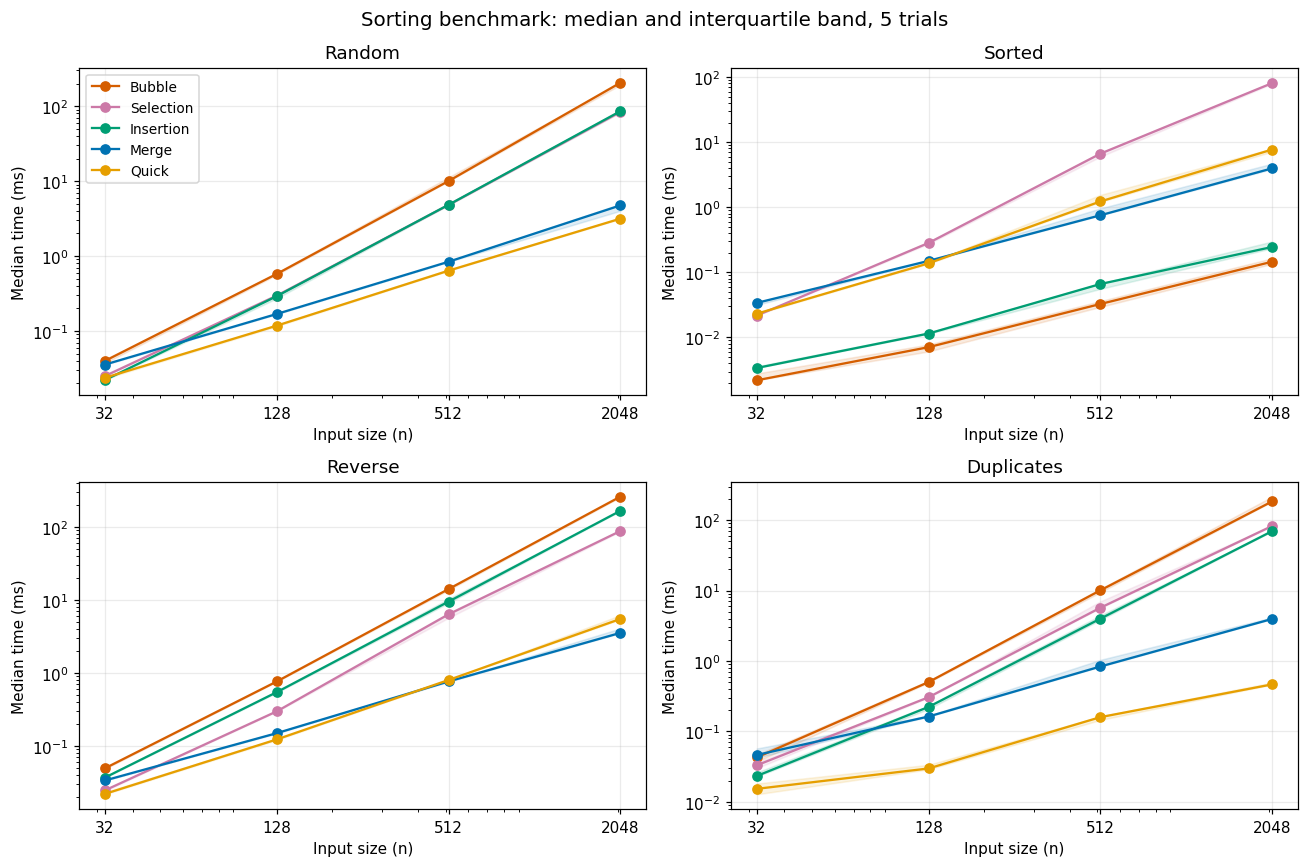

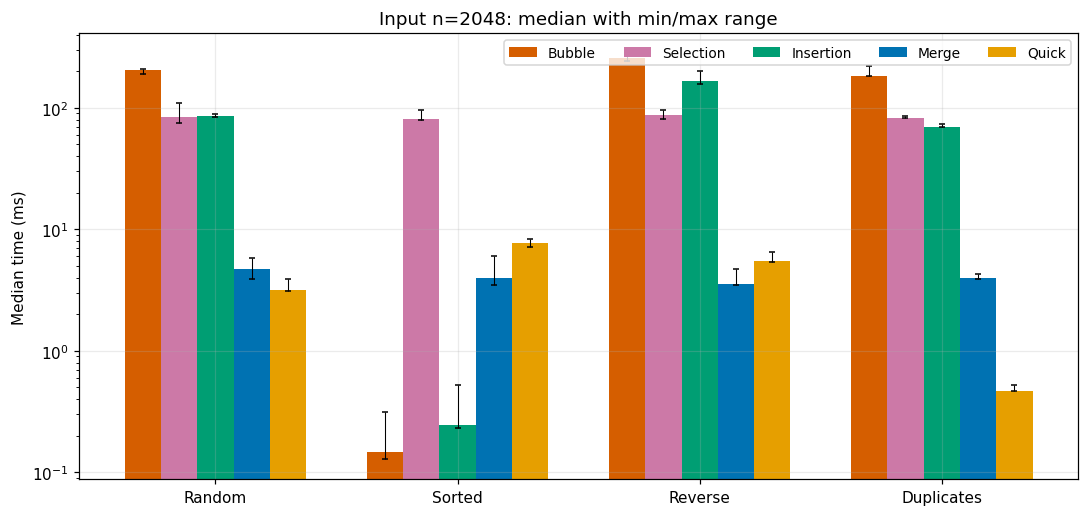

In [9]:
colors = {"Bubble": "#d55e00", "Selection": "#cc79a7", "Insertion": "#009e73",
          "Merge": "#0072b2", "Quick": "#e69f00"}
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, scenario in zip(axes.flat, SCENARIOS):
    for name in ALGORITHMS:
        medians = [summary[(scenario, size, name)]["median_ms"] for size in SIZES]
        lower = [summary[(scenario, size, name)]["q1_ms"] for size in SIZES]
        upper = [summary[(scenario, size, name)]["q3_ms"] for size in SIZES]
        ax.plot(SIZES, medians, marker="o", label=name, color=colors[name])
        ax.fill_between(SIZES, lower, upper, color=colors[name], alpha=0.12)
    ax.set(xscale="log", yscale="log", xlabel="Input size (n)", ylabel="Median time (ms)",
           title=scenario.capitalize())
    ax.set_xticks(SIZES, labels=[str(size) for size in SIZES])
axes[0, 0].legend(fontsize=9)
fig.suptitle("Sorting benchmark: median and interquartile band, 5 trials", fontsize=13)
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4.8))
bar_width = 0.15
for index, name in enumerate(ALGORITHMS):
    heights = [summary[(scenario, SIZES[-1], name)]["median_ms"] for scenario in SCENARIOS]
    errors = [[height - summary[(scenario, SIZES[-1], name)]["min_ms"]
               for height, scenario in zip(heights, SCENARIOS)],
              [summary[(scenario, SIZES[-1], name)]["max_ms"] - height
               for height, scenario in zip(heights, SCENARIOS)]]
    ax.bar([i + (index - 2) * bar_width for i in range(len(SCENARIOS))], heights,
           width=bar_width, color=colors[name], label=name, yerr=errors,
           capsize=2, error_kw={"linewidth": 0.7})
ax.set_xticks(range(len(SCENARIOS)), labels=[scenario.capitalize() for scenario in SCENARIOS])
ax.set(yscale="log", ylabel="Median time (ms)", title=f"Input n={SIZES[-1]}: median with min/max range")
ax.legend(ncol=5, fontsize=9)
fig.tight_layout()
plt.show()


### رتبه‌بندی نظری

- رتبهٔ ورودی تصادفی بزرگ با کلیدهای عمدتاً متمایز: ادغامی و سریع از نظر متوسط در گروه خطی‌لگاریتمی‌اند؛ حبابی، انتخابی و درجی در گروه درجهٔ دو هستند. از مرتبهٔ یکسان نمی‌توان ترتیب سرعت درون هر گروه را نتیجه گرفت.
- رتبهٔ ورودی مرتب: درجی و حبابی توقف‌دار زمان خطی دارند؛ ادغامی این نسخه خطی‌لگاریتمی و انتخابی درجهٔ دو است. رفتار سریع به تقسیم‌های حاصل از بخش‌بندی بستگی دارد؛ انتخاب میانهٔ سه تضمین کلی بدترین حالت نمی‌دهد.
- رتبهٔ ورودی معکوس با کلیدهای متمایز: حبابی، انتخابی و درجی درجهٔ دو هستند؛ ادغامی خطی‌لگاریتمی است. سریع با تقسیم‌های متوازن خطی‌لگاریتمی می‌شود، ولی این شرط باید از ورودی و نسخه سنجیده شود.
- رتبهٔ ورودی پرتکرار: سریع سه‌راهه بخش برابر را کنار می‌گذارد. با تعداد ثابت کلیدهای ممکن، هر عضو حداکثر به تعداد آن کلیدها در بخش‌بندی‌ها شرکت می‌کند و زمان این نسخه خطی است. درجی و حبابی هنوز می‌توانند وارونگی‌های درجهٔ دو داشته باشند؛ صرف وجود تکرار برای خطی‌شدن آن‌ها کافی نیست. ادغامی خطی‌لگاریتمی و انتخابی درجهٔ دو باقی می‌مانند.
- رتبهٔ تضمین بدترین حالت: ادغامی زمان خطی‌لگاریتمی تضمین می‌کند؛ چهار الگوریتم دیگر بدترین زمان درجهٔ دو دارند. تضمین رشد، رتبه‌بندی زمان واقعی یک ورودی خاص نیست.


### رتبه‌بندی تجربی

رتبه‌ها برای تک‌تک نوع‌ها و اندازه‌ها از زمان‌های همین اجرا محاسبه می‌شوند. ترتیب ثابت برای همهٔ ورودی‌ها وجود ندارد و اختلاف‌های کوچک می‌توانند ناشی از نوسان باشند. متغیر `raw_results` همهٔ ۴۰۰ زمان خام را نگه می‌دارد؛ جدول آخر فقط ده ردیف اول را برای آشنایی با ساختار نشان می‌دهد.


In [10]:
def empirical_order(scenario, size):
    return sorted(ALGORITHMS, key=lambda name: summary[(scenario, size, name)]["median_ms"])

rank_rows = []
for scenario in SCENARIOS:
    for size in SIZES:
        order = empirical_order(scenario, size)
        rank_rows.append((SCENARIO_NAMES[scenario], f"تعداد {size}",
                          " سپس ".join(PERSIAN_NAMES[name] for name in order)))
show_table(["نوع ورودی", "اندازه", "ترتیب تجربی از سریع‌تر به کندتر"], rank_rows)

display(Markdown("نکتهٔ خواندن رتبه‌ها: ترتیب بر اساس میانه همین اجرای محلی است. "
                 "هم‌پوشانی بازه پراکندگی به معنی آن است که تفاوت کوچک را نباید نتیجه قطعی دانست."))
for scenario in SCENARIOS:
    winner = empirical_order(scenario, SIZES[-1])[0]
    print("برنده تجربی در ورودی", SCENARIO_NAMES[scenario], "با اندازه", SIZES[-1], ":", PERSIAN_NAMES[winner])

# داده خام در حافظه نوت‌بوک برای محاسبه مجدد یا بررسی تک‌تک اجراها در دسترس است.
show_table(["ردیف", "نوع ورودی", "اندازه", "تکرار", "الگوریتم", "زمان به نانوثانیه"],
           [(f"نمونه {i}", SCENARIO_NAMES[row["scenario"]], row["n"], row["repeat"],
             PERSIAN_NAMES[row["algorithm"]], row["elapsed_ns"])
            for i, row in enumerate(raw_results[:10], 1)])


| نوع ورودی | اندازه | ترتیب تجربی از سریع‌تر به کندتر |
|---|---|---|
| تصادفی | تعداد 32 | درجی سپس سریع سپس انتخابی سپس ادغامی سپس حبابی |
| تصادفی | تعداد 128 | سریع سپس ادغامی سپس درجی سپس انتخابی سپس حبابی |
| تصادفی | تعداد 512 | سریع سپس ادغامی سپس انتخابی سپس درجی سپس حبابی |
| تصادفی | تعداد 2048 | سریع سپس ادغامی سپس انتخابی سپس درجی سپس حبابی |
| مرتب | تعداد 32 | حبابی سپس درجی سپس انتخابی سپس سریع سپس ادغامی |
| مرتب | تعداد 128 | حبابی سپس درجی سپس سریع سپس ادغامی سپس انتخابی |
| مرتب | تعداد 512 | حبابی سپس درجی سپس ادغامی سپس سریع سپس انتخابی |
| مرتب | تعداد 2048 | حبابی سپس درجی سپس ادغامی سپس سریع سپس انتخابی |
| معکوس | تعداد 32 | سریع سپس انتخابی سپس ادغامی سپس درجی سپس حبابی |
| معکوس | تعداد 128 | سریع سپس ادغامی سپس انتخابی سپس درجی سپس حبابی |
| معکوس | تعداد 512 | ادغامی سپس سریع سپس انتخابی سپس درجی سپس حبابی |
| معکوس | تعداد 2048 | ادغامی سپس سریع سپس انتخابی سپس درجی سپس حبابی |
| پرتکرار | تعداد 32 | سریع سپس درجی سپس انتخابی سپس حبابی سپس ادغامی |
| پرتکرار | تعداد 128 | سریع سپس ادغامی سپس درجی سپس انتخابی سپس حبابی |
| پرتکرار | تعداد 512 | سریع سپس ادغامی سپس درجی سپس انتخابی سپس حبابی |
| پرتکرار | تعداد 2048 | سریع سپس ادغامی سپس درجی سپس انتخابی سپس حبابی |

نکتهٔ خواندن رتبه‌ها: ترتیب بر اساس میانه همین اجرای محلی است. هم‌پوشانی بازه پراکندگی به معنی آن است که تفاوت کوچک را نباید نتیجه قطعی دانست.

برنده تجربی در ورودی تصادفی با اندازه 2048 : سریع
برنده تجربی در ورودی مرتب با اندازه 2048 : حبابی
برنده تجربی در ورودی معکوس با اندازه 2048 : ادغامی
برنده تجربی در ورودی پرتکرار با اندازه 2048 : سریع


| ردیف | نوع ورودی | اندازه | تکرار | الگوریتم | زمان به نانوثانیه |
|---|---|---|---|---|---|
| نمونه 1 | تصادفی | 32 | 1 | سریع | 27000 |
| نمونه 2 | تصادفی | 32 | 1 | انتخابی | 26200 |
| نمونه 3 | تصادفی | 32 | 1 | حبابی | 40200 |
| نمونه 4 | تصادفی | 32 | 1 | ادغامی | 36700 |
| نمونه 5 | تصادفی | 32 | 1 | درجی | 22500 |
| نمونه 6 | تصادفی | 32 | 2 | حبابی | 40600 |
| نمونه 7 | تصادفی | 32 | 2 | انتخابی | 25100 |
| نمونه 8 | تصادفی | 32 | 2 | سریع | 23200 |
| نمونه 9 | تصادفی | 32 | 2 | درجی | 23800 |
| نمونه 10 | تصادفی | 32 | 2 | ادغامی | 36000 |

## نتیجه و پیشنهاد آموزشی

نتیجهٔ نظری این است که ادغامی تضمین رشد بهتری در بدترین حالت دارد، درجی و حبابی توقف‌دار روی دادهٔ مرتب خطی‌اند و سریع سه‌راهه برای کلیدهای تکراری مناسب است. سرعت عملی باید برای اندازه و توزیع هدف سنجیده شود؛ پایداری، حافظه و تضمین بدترین حالت نیز در انتخاب الگوریتم نقش دارند.

پیشنهاد تمرین: بذر، اندازه‌ها یا تعداد مقدارهای ورودی پرتکرار را تغییر دهید و همهٔ سلول‌ها را دوباره اجرا کنید. سپس حدس نظری خود را با نمودار مقایسه کنید؛ صرف تغییر ثابت زمانی را کاهش مرتبهٔ پیچیدگی ننامید.

راهنمای اجرا و نسخه‌های وابستگی در `README.md` آمده است. نتایج ذخیره‌شده مربوط به اجرای تحویل‌اند؛ اجرای تازه جدول‌ها و نمودارها را به‌روز می‌کند. فلوچارت‌های پیوست بدون اجرای کد نیز قابل مشاهده‌اند.
